# Multivariate Regression Covid

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
cwd = os.getcwd()
print(cwd)

c:\Users\danie\Documents\GitHub\thesis\modelling


In [3]:
df = pd.read_csv('../Data/gold/covid_multivariate_w_2.csv')
df.head()

,date,country,new_cases,cases,co,no2,o3,pm10,pm25,so2,population,google_physician,google_hospital,google_pharmacy,google_symptom,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated
0,2020-03-23,Chile,1558,10261,5.828571,5.242857,10.619048,28.350649,37.952381,3.773810,19331414,30,8,9,32,19.456667,69.844286,0.0
1,2020-03-30,Chile,2420,24909,5.978571,6.516667,13.771429,38.922078,50.726190,4.035714,19331414,27,7,10,28,12.998571,75.930000,0.0
2,2020-04-06,Chile,2987,43938,6.235714,6.992857,12.733333,43.142857,66.071429,3.840476,19331414,28,7,9,25,11.041429,75.930000,0.0
3,2020-04-13,Chile,3304,65523,7.383333,8.771429,11.707143,43.233766,69.059524,4.076190,19331414,28,6,9,21,10.270000,75.930000,0.0
4,2020-04-20,Chile,4054,90640,6.742857,6.788095,11.769048,38.662338,63.321429,3.661905,19331414,24,6,9,21,10.878571,75.930000,0.0


In [4]:
df['country'].unique()

array(['Chile', 'Colombia', 'Italy', 'Mexico', 'US'], dtype=object)

# Wrangle

In [5]:
df.columns

Index(['date', 'country', 'new_cases', 'cases', 'co', 'no2', 'o3', 'pm10',
       'pm25', 'so2', 'population', 'google_physician', 'google_hospital',
       'google_pharmacy', 'google_symptom', 'Mean_distance_avg_14day_movavg',
       'StringencyIndex_Average', 'pop_vaccinated'],
      dtype='object')

In [6]:
df.rename(columns={'Mean_distance_avg_14day_movavg':'14d_avg_dist',
                    'StringencyIndex_Average':'StringencyIndex'}, inplace = True)

In [7]:
df['cases_t_4'] = df.groupby('country')['cases'].shift(-4)
df['cases_t_1'] = df.groupby('country')['cases'].shift(-1)

In [8]:
df['cases_lag1'] = df.groupby('country')['cases'].shift(1)

In [9]:
print(df['cases_t_4'].isnull().sum(), 'Nans for cases_t_4')
print(df['cases_t_1'].isnull().sum(), 'Nans for cases_t_1')
print(df['cases_lag1'].isnull().sum(), 'Nans for cases_lag1')

20 Nans for cases_t_4
5 Nans for cases_t_1
5 Nans for cases_lag1


In [10]:
# drop if cases_t_4 is null
df = df.dropna(subset=['cases_t_4'])
df = df.dropna(subset=['cases_t_1'])
df = df.dropna(subset=['cases_lag1'])

In [11]:
# convert date to numeric
df['date'] = pd.to_datetime(df['date'])
df['date_numeric'] = df['date'].apply(lambda x: x.timestamp())

In [12]:
df_og = df.copy()

In [13]:
# dummies for countries
df = pd.get_dummies(df, columns=['country'], drop_first=True)

# Regression Framework

In [14]:
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler


def plot_country_residuals_scaled(df, target,model):
    countries = df['country'].unique()
    n_countries = len(countries)
    
    fig, axes = plt.subplots(nrows=2, ncols=(n_countries + 1) // 2, figsize=(15, 10))
    axes = axes.flatten()

    for idx, country in enumerate(countries):
        # Filter data for the current country
        df_country = df[df['country'] == country]

        # Define explanatory and target variables
        if target == 'new_cases':
            y = df_country['new_cases']
            X = df_country.drop(columns=['cases','new_cases', 'cases_t_4','cases_t_1', 'date', 'country'])
        elif target == 'cases':
            y = df_country['cases']
            X = df_country.drop(columns = ['cases','new_cases', 'cases_t_4','cases_t_1', 'date', 'country'])
        elif target == 'cases_t_4':
            y = df_country['cases_t_4']
            X = df_country.drop(columns = ['cases_t_4','cases_t_1', 'date', 'country'])
        elif target == 'cases_t_1':
            y = df_country['cases_t_1']
            X = df_country.drop(columns = ['cases_t_4','cases_t_1', 'date', 'country'])
        
        

        # Split data (80/20 split, time-series style)
        split_idx = int(len(df_country) * 0.8)
        X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
        y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
        dates_test = df_country['date'].iloc[split_idx:]

        # Scale data
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Fit provided model on scaled data
        model.fit(X_train_scaled, y_train)

        # Predict and compute residuals
        y_pred = model.predict(X_test_scaled)
        residuals = y_test - y_pred

        # Calculate MSE
        mse = mean_squared_error(y_test, y_pred)

        # Plot residuals
        ax = axes[idx]
        ax.plot(dates_test, residuals, marker='o', linestyle='-', markersize=3)
        ax.axhline(y=0, color='red', linestyle='--')
        ax.set_title(f"{country} Residuals (MSE: {mse:.2f})")
        ax.set_xlabel("Date")
        ax.set_ylabel("Residual")
        ax.tick_params(axis='x', rotation=45)

    # Remove any empty subplots
    for idx in range(n_countries, len(axes)):
        fig.delaxes(axes[idx])

    fig.tight_layout()
    plt.show()

# Example usage:
# from sklearn.linear_model import Lasso
# plot_country_residuals(df_og, Lasso(alpha=1.0))


# OLS

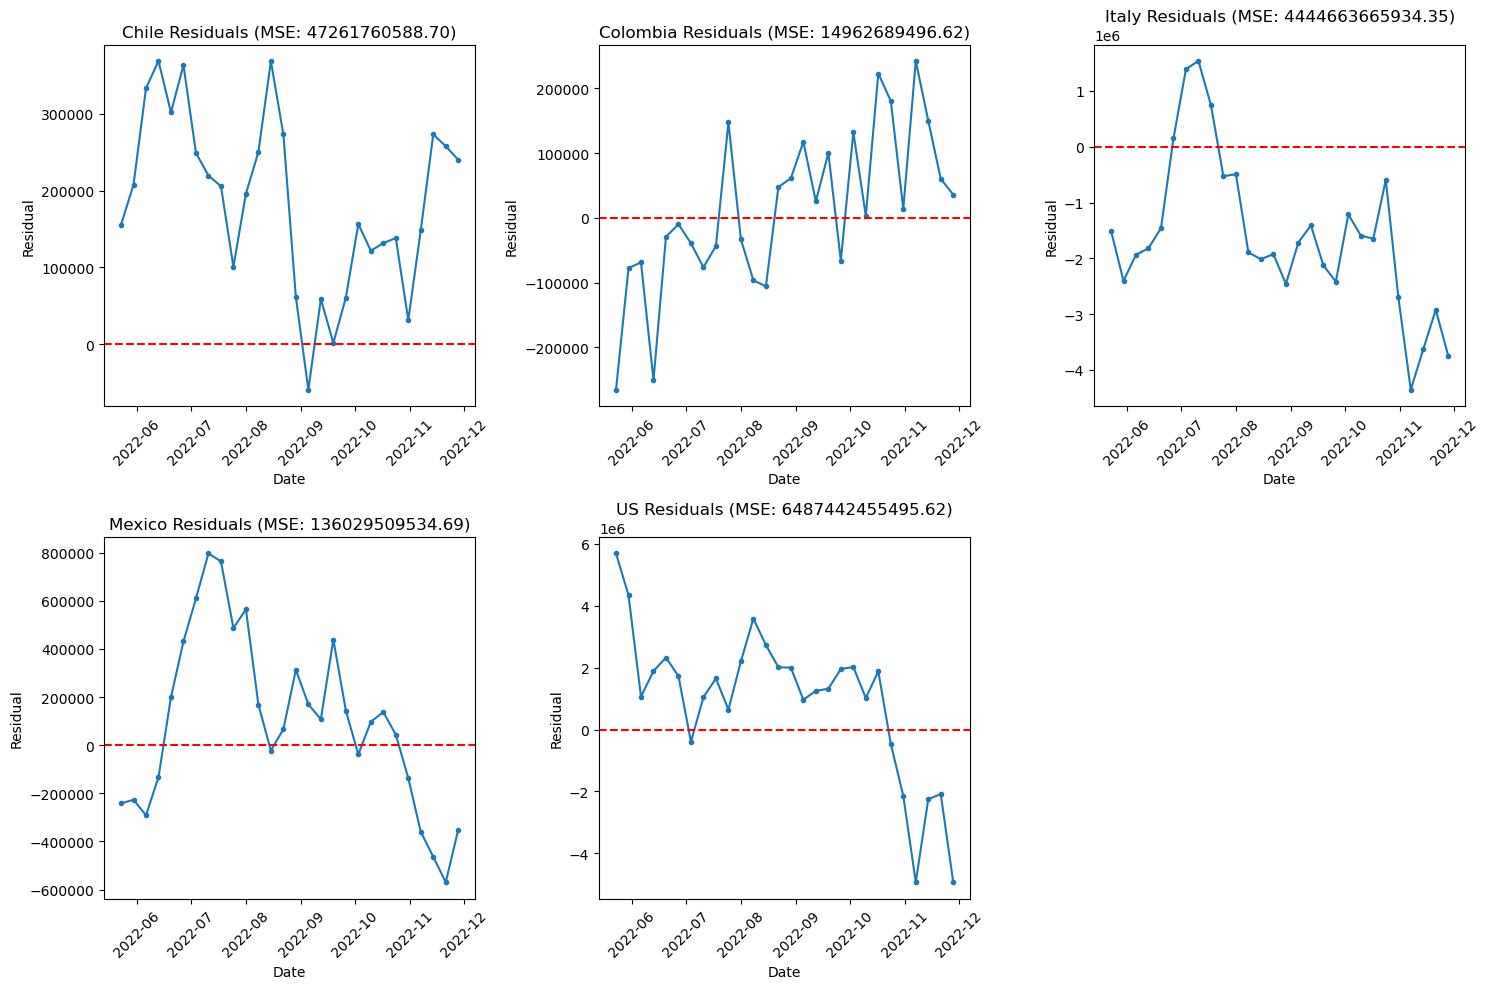

In [15]:
from sklearn.linear_model import LinearRegression
plot_country_residuals_scaled(df_og,'cases', LinearRegression())

## Lasso

c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.130e+12, tolerance: 1.777e+12
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.758e+14, tolerance: 3.602e+14
  model = cd_fast.enet_coordinate_descent(


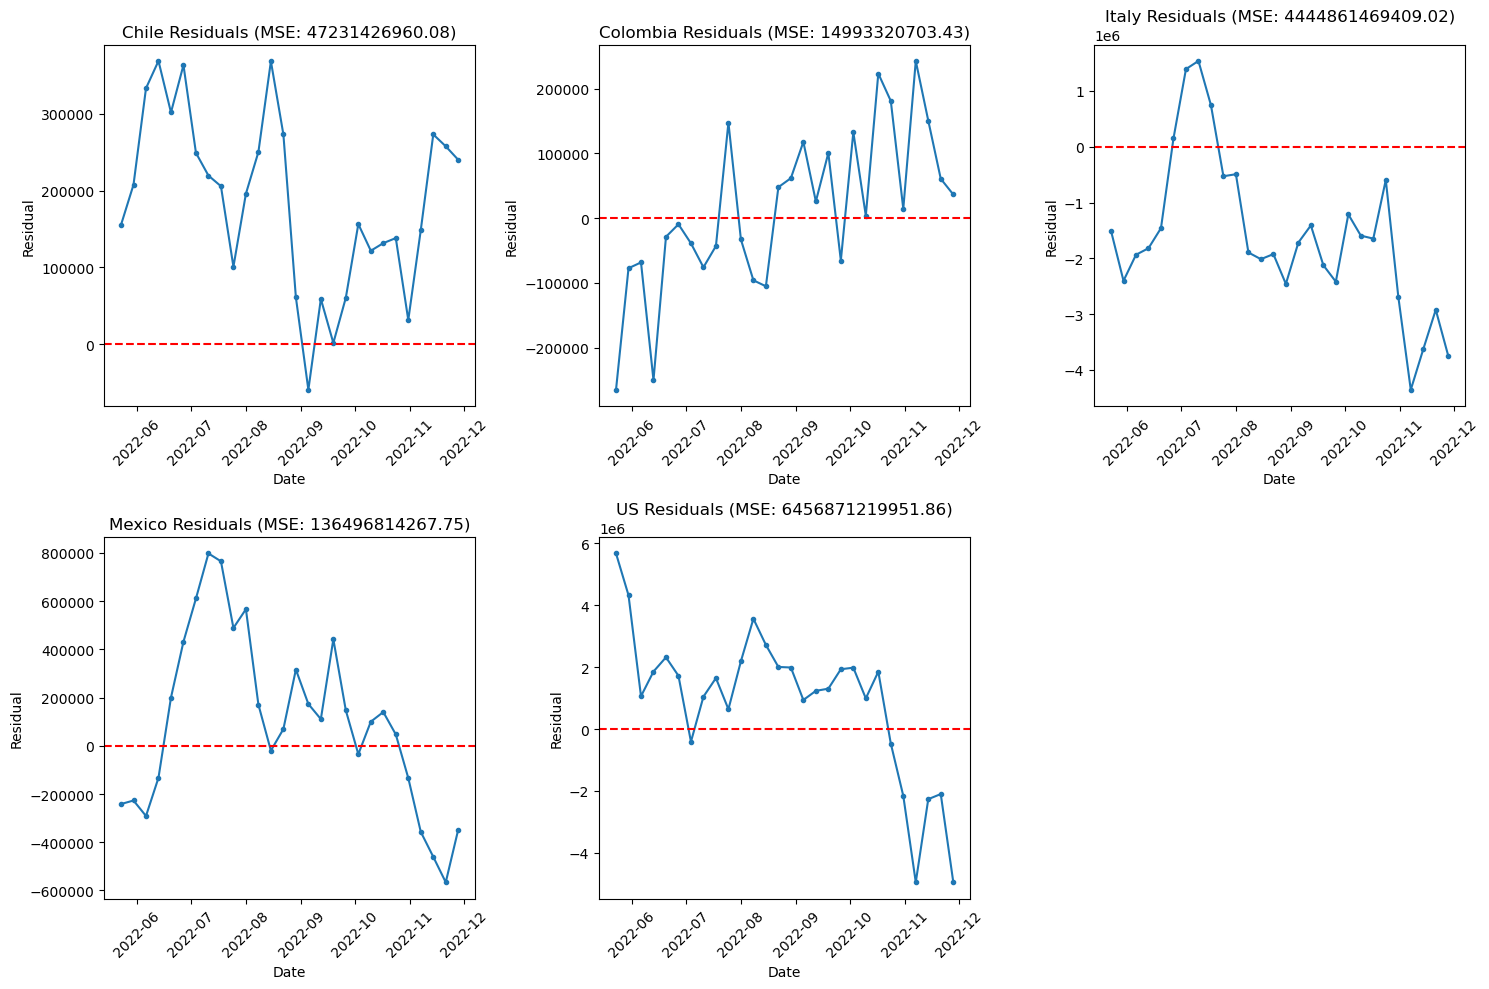

In [16]:
from sklearn.linear_model import Lasso
plot_country_residuals_scaled(df_og,'cases', Lasso(alpha=1.0))

## Ridge

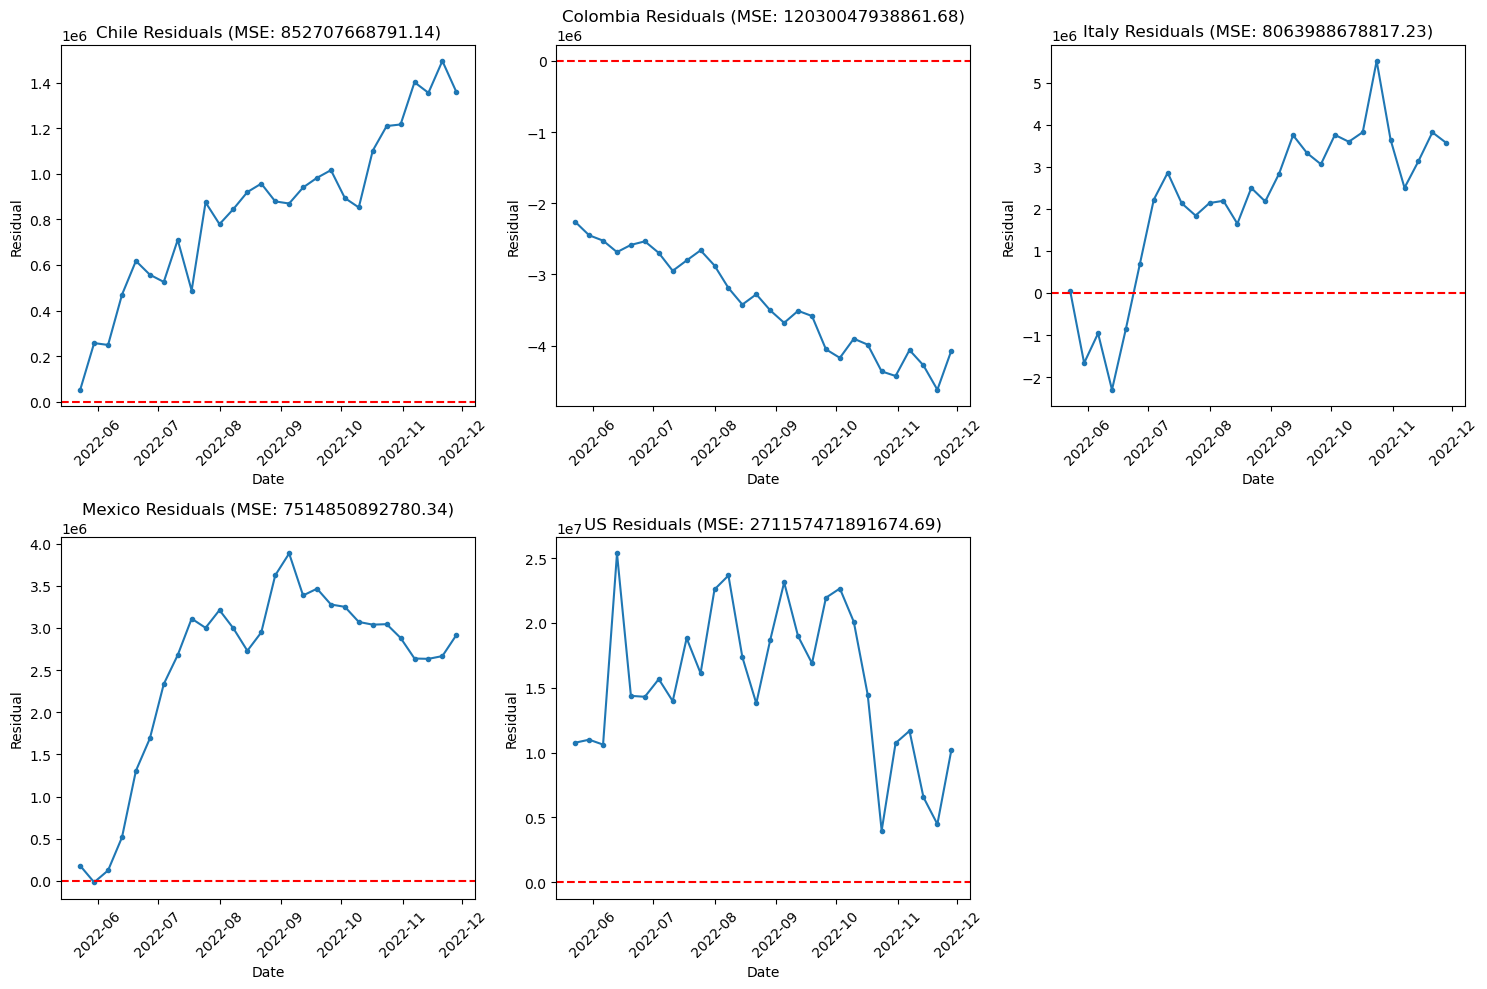

In [17]:
from sklearn.linear_model import Ridge
plot_country_residuals_scaled(df_og, 'cases',Ridge(alpha=1.0))

## Elastic Net

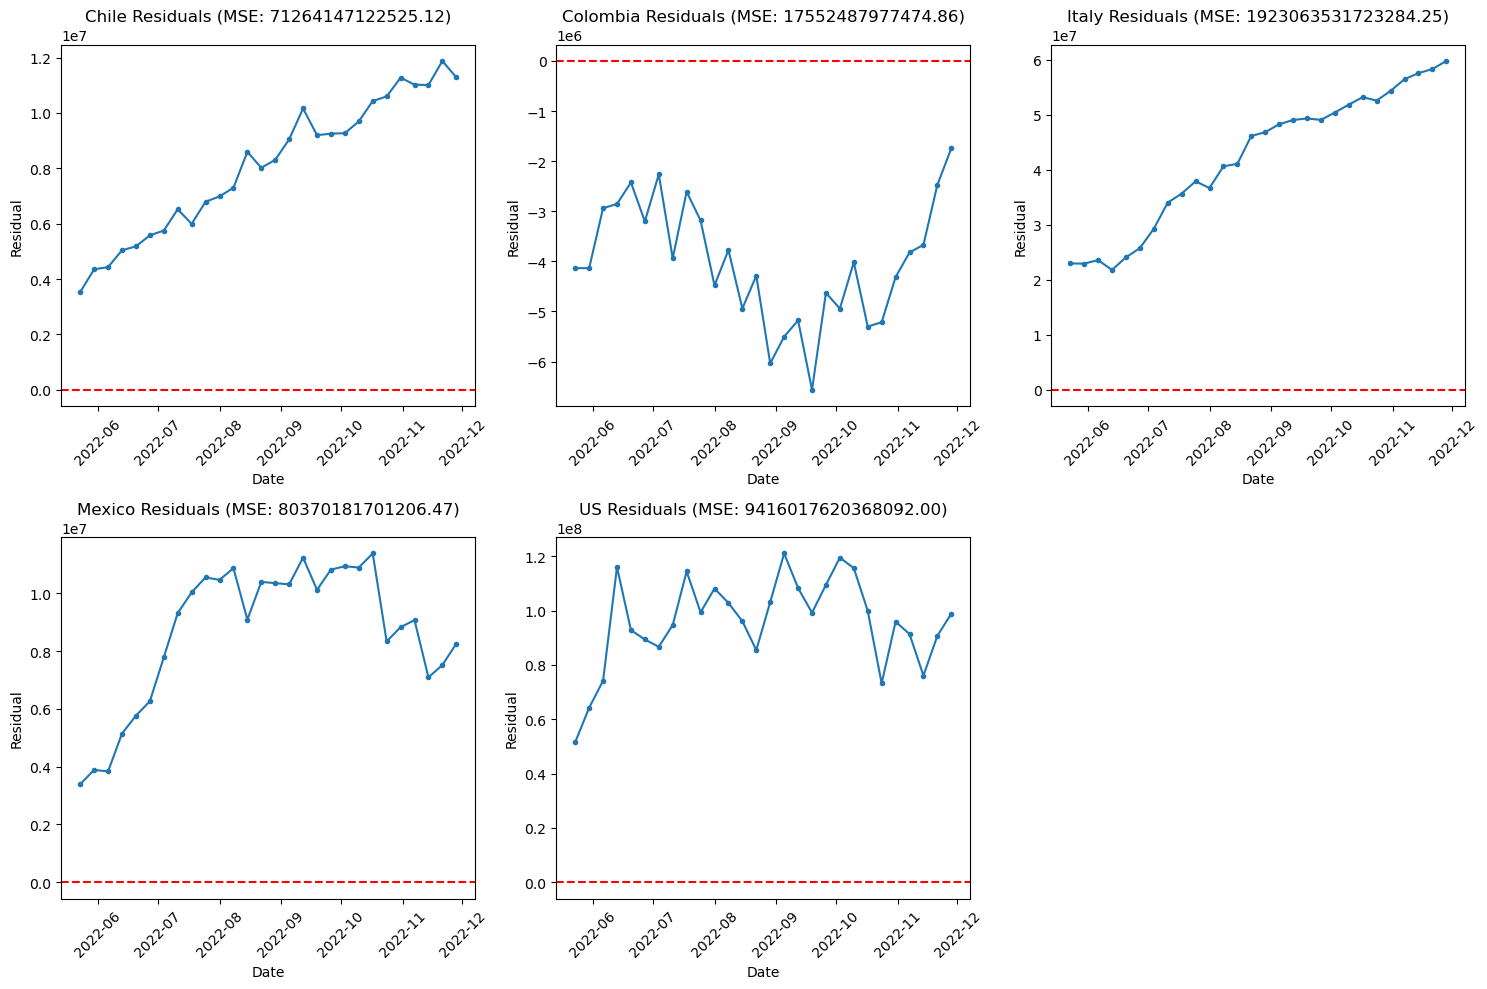

In [18]:
from sklearn.linear_model import ElasticNet
plot_country_residuals_scaled(df_og,'cases', ElasticNet(alpha=1.0, l1_ratio=0.5))

## Random Forest

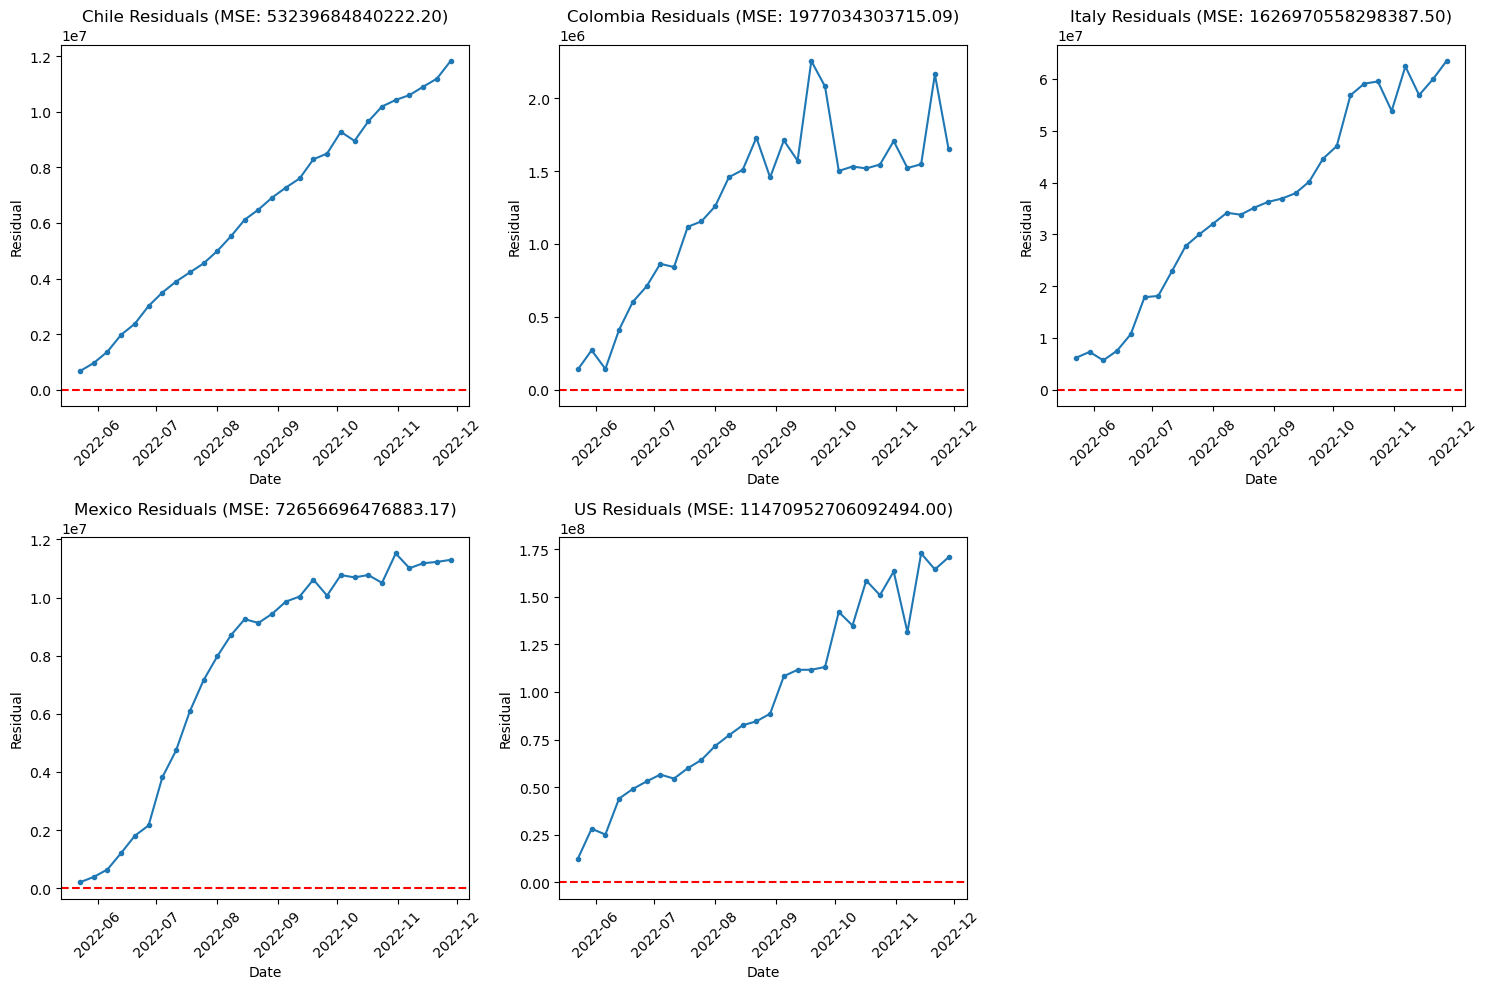

In [19]:
from sklearn.ensemble import RandomForestRegressor
plot_country_residuals_scaled(df_og,'cases', RandomForestRegressor())

## Gradient Boosting

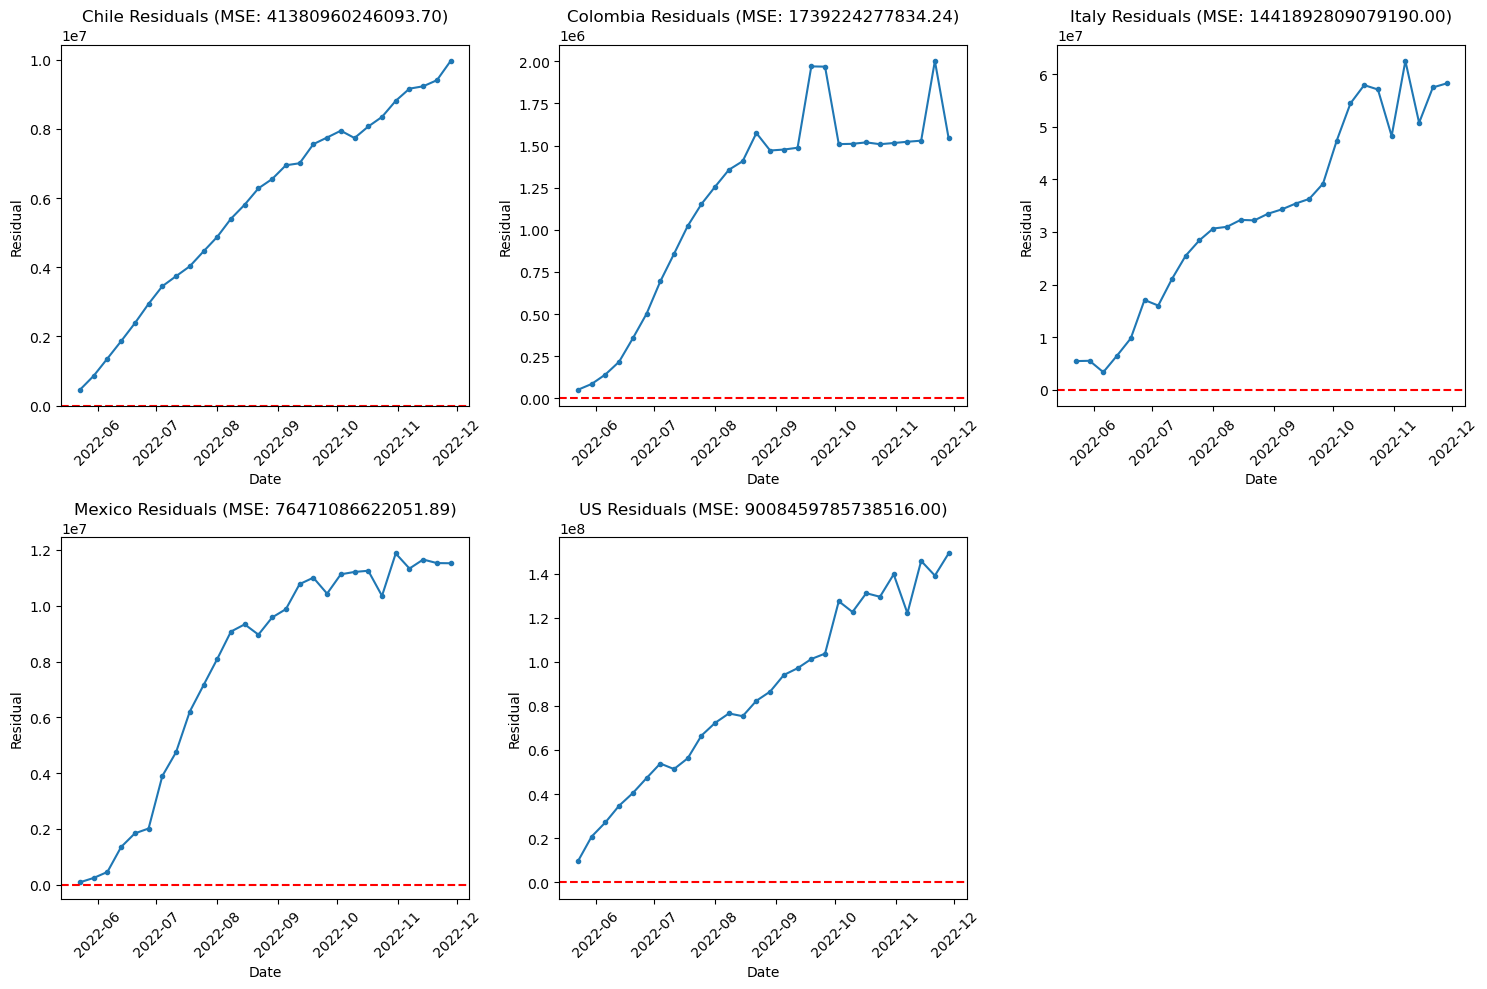

In [20]:
from sklearn.ensemble import GradientBoostingRegressor
plot_country_residuals_scaled(df_og, 'cases',GradientBoostingRegressor())

## SVM

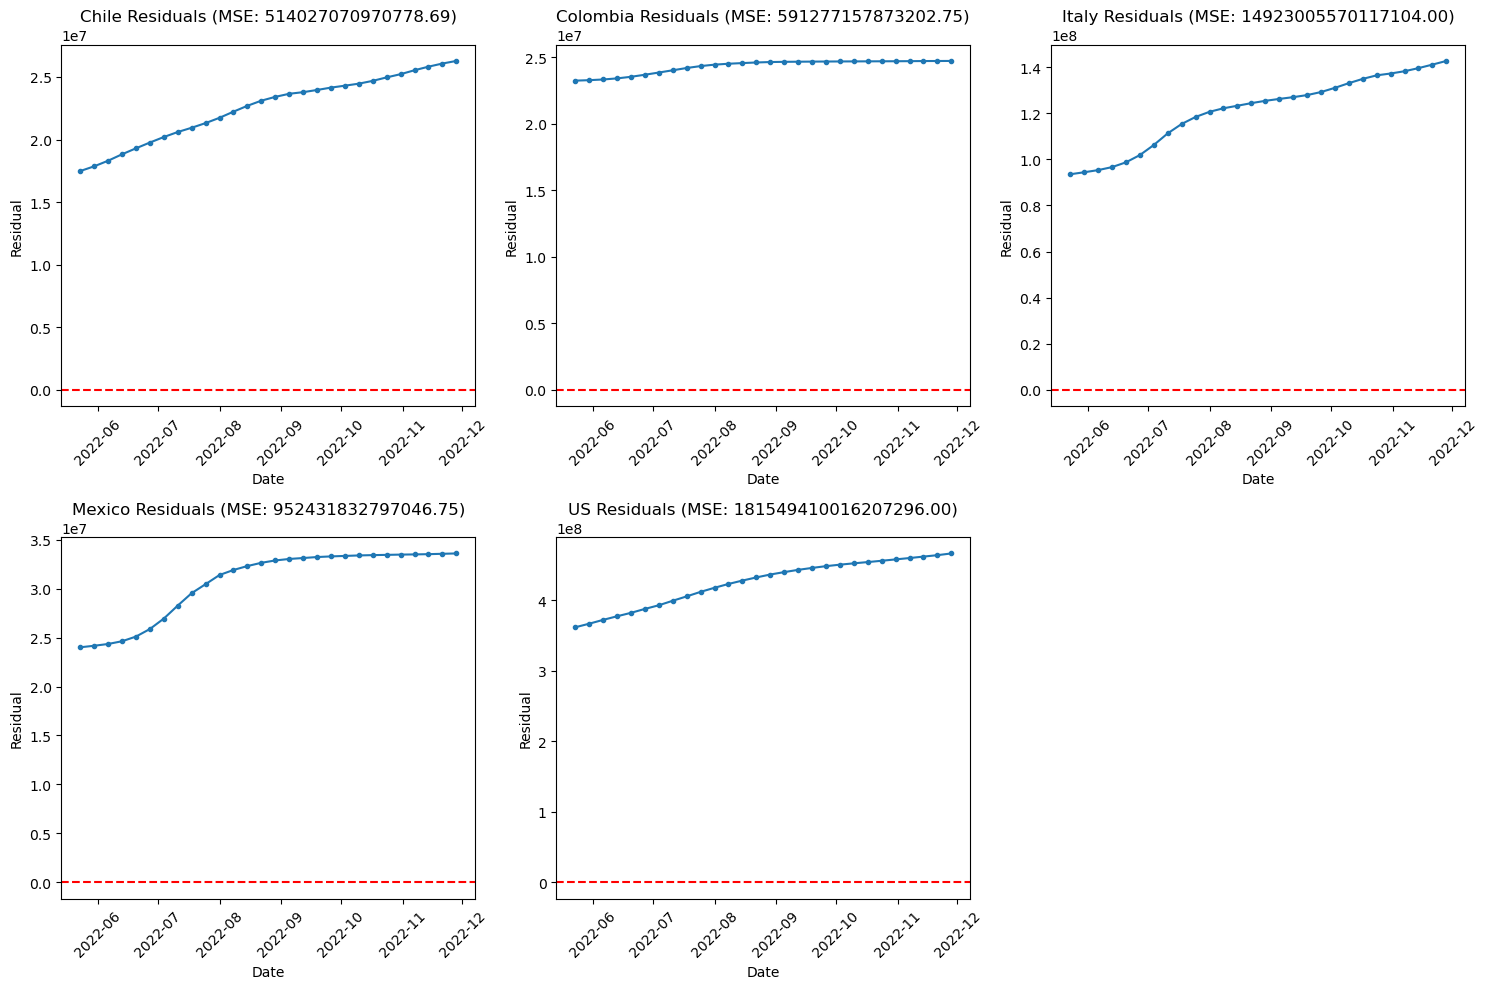

In [21]:
# do SVM regression
from sklearn.svm import SVR
plot_country_residuals_scaled(df_og,'cases', SVR(kernel='rbf'))

The models dont capture the trend, even by including the laged cases (cumulative) as a regressor

## Metrics

In [22]:

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import make_scorer


def evaluate_country_metrics_cv(df, target_variable, model, n_splits=5):
    country_names = df['country'].unique()

    metrics = {}

    for country_name in country_names:
        country_df = df[df['country'] == country_name].reset_index(drop=True)

        if len(country_df) == 0:
            print(f"No data available for {country_name}. Skipping...")
            continue

        split_country_idx = int(len(country_df) * 0.8)

        drop_columns = [target_variable, 'date', 'country']
        if target_variable == 'new_cases':
            drop_columns.extend(['cases', 'cases_t_4', 'cases_t_1'])
        elif target_variable == 'cases_t_4':
            drop_columns.extend(['cases_lag1', 'cases_t_1'])
        elif target_variable == 'cases_t_1':
            drop_columns.extend(['cases_lag1', 'cases_t_4'])
        elif target_variable == 'cases':
            drop_columns.extend(['new_cases', 'cases_t_4', 'cases_t_1'])

        X_country = country_df.drop(columns=drop_columns)
        y_country = country_df[target_variable]

        X_train, X_test = X_country.iloc[:split_country_idx], X_country.iloc[split_country_idx:]
        y_train, y_test = y_country.iloc[:split_country_idx], y_country.iloc[split_country_idx:]

        if len(y_train) == 0 or y_train.nunique() == 1:
            print(f"Skipping {country_name} due to insufficient or constant target values.")
            continue

        dummy_cols = [col for col in X_country.columns if set(X_country[col].unique()) <= {0, 1}]
        numeric_cols = [col for col in X_country.columns if col not in dummy_cols]

        scaler = StandardScaler()
        X_train_scaled_numeric = scaler.fit_transform(X_train[numeric_cols])
        X_test_scaled_numeric = scaler.transform(X_test[numeric_cols])

        X_train_scaled = np.concatenate([X_train_scaled_numeric, X_train[dummy_cols].values], axis=1)
        X_test_scaled = np.concatenate([X_test_scaled_numeric, X_test[dummy_cols].values], axis=1)

        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        mse_scores = cross_val_score(model, X_train_scaled, y_train, 
                                     scoring=make_scorer(mean_squared_error), cv=kf)
        rmse_cv = np.sqrt(mse_scores).mean()

        r2_cv = cross_val_score(model, X_train_scaled, y_train, scoring='r2', cv=kf).mean()

        model.fit(X_train_scaled, y_train)
        y_pred_test = model.predict(X_test_scaled)

        rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
        r2_test = r2_score(y_test, y_pred_test)

        metrics[country_name] = {
            'RMSE_CV': rmse_cv,
            'R2_CV': r2_cv,
            'RMSE_Test': rmse_test,
            'R2_Test': r2_test
        }

    return metrics


In [23]:
def evaluate_models_rmse(df, target_variable):
    models = {
        'LinearRegression': LinearRegression(),
        'Lasso': Lasso(alpha=1.0),
        'Ridge': Ridge(alpha=1.0),
        'ElasticNet': ElasticNet(alpha=1.0, l1_ratio=0.5),
        'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
        'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
        'SVR': SVR(kernel='rbf')
    }

    all_metrics = []

    for model_name, model in models.items():
        metrics = evaluate_country_metrics_cv(df, target_variable, model)
        for country, scores in metrics.items():
            all_metrics.append({
                'Model': model_name,
                'Country': country,
                'RMSE': scores['RMSE_Test'],
                'R2': scores['R2_Test']
            })

    metrics_df = pd.DataFrame(all_metrics)
    return metrics_df



In [24]:
df_metrics_all = evaluate_models_rmse(df_og, 'cases')
df_metrics_all

c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.654e+12, tolerance: 1.460e+12
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.754e+12, tolerance: 1.461e+12
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisati

,Model,Country,RMSE,R2
0,LinearRegression,Chile,2.173977e+05,0.993065
1,LinearRegression,Colombia,1.223221e+05,0.944242
2,LinearRegression,Italy,2.108237e+06,0.981176
3,LinearRegression,Mexico,3.688218e+05,0.989046
4,LinearRegression,US,2.547046e+06,0.993913
5,Lasso,Chile,2.173279e+05,0.993069
6,Lasso,Colombia,1.224472e+05,0.944128
7,Lasso,Italy,2.108284e+06,0.981175
8,Lasso,Mexico,3.694548e+05,0.989008
9,Lasso,US,2.541037e+06,0.993941


In [25]:
df_rmse_pivot = df_metrics_all.pivot(index = 'Country', columns='Model', values='RMSE').reset_index()
df_rmse_pivot

Model,Country,ElasticNet,GradientBoosting,Lasso,LinearRegression,RandomForest,Ridge,SVR
0,Chile,8.441809e+06,6.741888e+06,2.173279e+05,2.173977e+05,7.258473e+06,9.234217e+05,2.267217e+07
1,Colombia,4.189569e+06,1.319308e+06,1.224472e+05,1.223221e+05,1.430908e+06,3.468436e+06,2.431619e+07
2,Italy,4.385275e+07,3.916553e+07,2.108284e+06,2.108237e+06,4.115178e+07,2.839716e+06,1.221598e+08
3,Mexico,8.964942e+06,8.945718e+06,3.694548e+05,3.688218e+05,8.818598e+06,2.741323e+06,3.086149e+07
4,US,9.703617e+07,9.116767e+07,2.541037e+06,2.547046e+06,1.048573e+08,1.646686e+07,4.260862e+08


In [26]:
df_r2_pivot = df_metrics_all.pivot(index = 'Country', columns='Model', values='R2').reset_index()
df_r2_pivot

Model,Country,ElasticNet,GradientBoosting,Lasso,LinearRegression,RandomForest,Ridge,SVR
0,Chile,-9.457739,-5.670061,0.993069,0.993065,-6.731383,0.874868,-74.431494
1,Colombia,-64.408781,-5.486189,0.944128,0.944242,-6.629935,-43.829586,-2202.375275
2,Italy,-7.144698,-5.496650,0.981175,0.981176,-6.172305,0.965847,-62.202997
3,Mexico,-5.472102,-5.444375,0.989008,0.989046,-5.262526,0.394839,-75.698050
4,US,-7.835486,-6.799107,0.993941,0.993913,-9.317171,0.745560,-169.356223


In [27]:
df_metrics_all_t1 = evaluate_models_rmse(df_og, 'cases_t_1')
df_rmse_pivot_t1 = df_metrics_all_t1.pivot(index = 'Country', columns='Model', values='RMSE').reset_index()
df_rmse_pivot_t1

Model,Country,ElasticNet,GradientBoosting,Lasso,LinearRegression,RandomForest,Ridge,SVR
0,Chile,8.545518e+06,7.276467e+06,4.509980e+04,4.043284e+04,7.678303e+06,9.634869e+05,2.269871e+07
1,Colombia,3.983888e+06,1.321752e+06,1.147677e+05,1.480721e+05,1.455460e+06,3.324201e+06,2.355811e+07
2,Italy,4.545035e+07,3.601798e+07,3.282576e+05,3.276511e+05,3.946759e+07,4.967453e+06,1.233537e+08
3,Mexico,9.150194e+06,9.187983e+06,1.432651e+05,1.603401e+05,8.707002e+06,2.793362e+06,3.104774e+07
4,US,9.780122e+07,8.880795e+07,1.981908e+06,1.751053e+06,1.027448e+08,1.558946e+07,4.274534e+08


In [28]:
df_r2_pivot_t1 = df_metrics_all_t1.pivot(index = 'Country', columns='Model', values='R2').reset_index()
df_r2_pivot_t1

Model,Country,ElasticNet,GradientBoosting,Lasso,LinearRegression,RandomForest,Ridge,SVR
0,Chile,-10.491164,-7.331598,0.999680,0.999743,-8.277216,0.853924,-80.075512
1,Colombia,-67.543158,-6.544835,0.943116,0.905312,-8.148510,-46.722660,-2395.795712
2,Italy,-8.194201,-4.774020,0.999520,0.999522,-5.932992,0.890174,-66.724235
3,Mexico,-6.568189,-6.630829,0.998145,0.997676,-5.852810,0.294681,-86.134737
4,US,-8.763218,-7.050226,0.995991,0.996870,-9.775160,0.751934,-185.501347


In [29]:
df_metrics_all_t4 = evaluate_models_rmse(df_og, 'cases_t_4')
df_rmse_pivot_t4 = df_metrics_all_t4.pivot(index = 'Country', columns='Model', values='RMSE').reset_index()
df_rmse_pivot_t4

c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.480e+12, tolerance: 1.511e+12
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.323e+12, tolerance: 1.539e+12
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisati

Model,Country,ElasticNet,GradientBoosting,Lasso,LinearRegression,RandomForest,Ridge,SVR
0,Chile,8.333632e+06,7.639386e+06,3.186390e+05,3.186782e+05,7.553660e+06,1.062718e+06,2.273073e+07
1,Colombia,4.180177e+06,1.297426e+06,1.861296e+06,1.861223e+06,1.367516e+06,3.854216e+06,2.125680e+07
2,Italy,4.584612e+07,3.943713e+07,3.234668e+06,3.234677e+06,4.324125e+07,5.947889e+06,1.275927e+08
3,Mexico,8.779838e+06,8.789270e+06,1.096361e+06,1.097970e+06,8.932713e+06,2.712343e+06,3.167323e+07
4,US,8.485573e+07,7.668446e+07,2.199151e+07,2.201623e+07,9.346480e+07,1.671687e+07,4.334875e+08


In [30]:
df_r2_pivot_t4 = df_metrics_all_t4.pivot(index = 'Country', columns='Model', values='R2').reset_index()
df_r2_pivot_t4

Model,Country,ElasticNet,GradientBoosting,Lasso,LinearRegression,RandomForest,Ridge,SVR
0,Chile,-12.869138,-10.654611,0.979724,0.979719,-10.394512,0.774464,-102.182900
1,Colombia,-149.613600,-13.509097,-28.861093,-28.858764,-15.119058,-127.040382,-3893.669241
2,Italy,-11.086347,-7.943353,0.939834,0.939834,-9.751928,0.796570,-92.614141
3,Mexico,-11.229634,-11.255924,0.809301,0.808741,-11.659227,-0.167158,-158.156836
4,US,-8.596501,-6.837279,0.355444,0.353994,-10.642513,0.627556,-249.440057


# Explanatory variables

We now implement a version which compares all the countries in a single model so it can consider differences in variables such as population density

In [31]:
# plot predictions with history
def plot_predictions_cv(df, target_variable, model, n_splits=5):
    country_names = df['country'].unique()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, country_name in enumerate(country_names):
        country_df = df[df['country'] == country_name].reset_index(drop=True)

        if len(country_df) == 0:
            print(f"No data available for {country_name}. Skipping...")
            continue

        split_country_idx = int(len(country_df) * 0.8)

        drop_columns = [target_variable, 'date', 'country']
        if target_variable == 'new_cases':
            drop_columns.extend(['cases', 'cases_t_4', 'cases_t_1'])
        elif target_variable == 'cases_t_4':
            drop_columns.extend(['cases_lag1', 'cases_t_1'])
        elif target_variable == 'cases':
            drop_columns.extend(['new_cases', 'cases_t_4', 'cases_t_1'])

        X_country = country_df.drop(columns=drop_columns)
        y_country = country_df[target_variable]

        X_train, X_test = X_country.iloc[:split_country_idx], X_country.iloc[split_country_idx:]
        y_train, y_test = y_country.iloc[:split_country_idx], y_country.iloc[split_country_idx:]

        if len(y_train) == 0 or y_train.nunique() == 1:
            print(f"Skipping {country_name} due to insufficient or constant target values.")
            continue

        dummy_cols = [col for col in X_country.columns if set(X_country[col].unique()) <= {0, 1}]
        numeric_cols = [col for col in X_country.columns if col not in dummy_cols]

        scaler = StandardScaler()
        X_train_scaled_numeric = scaler.fit_transform(X_train[numeric_cols])
        X_test_scaled_numeric = scaler.transform(X_test[numeric_cols])

        X_train_scaled = np.concatenate([X_train_scaled_numeric, X_train[dummy_cols].values], axis=1)
        X_test_scaled = np.concatenate([X_test_scaled_numeric, X_test[dummy_cols].values], axis=1)

        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        mse_scores = cross_val_score(model, X_train_scaled, y_train, 
                                     scoring=make_scorer(mean_squared_error), cv=kf)
        rmse_cv = np.sqrt(mse_scores).mean()
        r2_cv = cross_val_score(model, X_train_scaled, y_train, scoring='r2', cv=kf).mean()

        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        axes[idx].plot(country_df['date'].iloc[split_country_idx:], y_test, label='Actual', color='blue')
        axes[idx].plot(country_df['date'].iloc[split_country_idx:], y_pred, label='Predicted', color='red', linestyle='--')

        axes[idx].set_title(f'{country_name}\nRMSE_CV: {rmse_cv:.2f}, R2_CV: {r2_cv:.2f}', fontsize=14)
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].set_xlabel('Date')
        axes[idx].set_ylabel(target_variable)
        axes[idx].legend()

    if len(country_names) < len(axes):
        for ax in axes[len(country_names):]:
            fig.delaxes(ax)

    plt.tight_layout()
    plt.show()



In [32]:
# plot only forecast (test)
def plot_predictions_cv_forecast(df, target_variable, model, n_splits=5):
    country_names = df['country'].unique()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, country_name in enumerate(country_names):
        country_df = df[df['country'] == country_name].reset_index(drop=True)

        if len(country_df) == 0:
            print(f"No data available for {country_name}. Skipping...")
            continue

        split_country_idx = int(len(country_df) * 0.8)

        drop_columns = [target_variable, 'date', 'country']
        if target_variable == 'new_cases':
            drop_columns.extend(['cases', 'cases_t_4', 'cases_t_1'])
        elif target_variable == 'cases_t_4':
            drop_columns.extend(['cases_lag1', 'cases_t_1'])
        elif target_variable == 'cases_t_1':
            drop_columns.extend(['cases_lag1', 'cases_t_4'])            
        elif target_variable == 'cases':
            drop_columns.extend(['new_cases', 'cases_t_4', 'cases_t_1'])

        X_country = country_df.drop(columns=drop_columns)
        y_country = country_df[target_variable]

        X_train, X_test = X_country.iloc[:split_country_idx], X_country.iloc[split_country_idx:]
        y_train, y_test = y_country.iloc[:split_country_idx], y_country.iloc[split_country_idx:]

        if len(y_train) == 0 or y_train.nunique() == 1:
            print(f"Skipping {country_name} due to insufficient or constant target values.")
            continue

        dummy_cols = [col for col in X_country.columns if set(X_country[col].unique()) <= {0, 1}]
        numeric_cols = [col for col in X_country.columns if col not in dummy_cols]

        scaler = StandardScaler()
        X_train_scaled_numeric = scaler.fit_transform(X_train[numeric_cols])
        X_test_scaled_numeric = scaler.transform(X_test[numeric_cols])

        X_train_scaled = np.concatenate([X_train_scaled_numeric, X_train[dummy_cols].values], axis=1)
        X_test_scaled = np.concatenate([X_test_scaled_numeric, X_test[dummy_cols].values], axis=1)

        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        axes[idx].plot(country_df['date'].iloc[split_country_idx:], y_test, label='Actual', color='blue')
        axes[idx].plot(country_df['date'].iloc[split_country_idx:], y_pred, label='Predicted', color='red', linestyle='--')

        axes[idx].set_title(f'{country_name}', fontsize=14)
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].set_xlabel('Date')
        axes[idx].set_ylabel(target_variable)
        axes[idx].legend()

    if len(country_names) < len(axes):
        for ax in axes[len(country_names):]:
            fig.delaxes(ax)

    plt.tight_layout()
    plt.show()


In [33]:
def plot_predictions_all(df, target_variable, model, n_splits=5):
    countries = df.filter(like='country_').columns
    country_names = [col.replace('country_', '') for col in countries]
    country_names.append('Chile')  # Chile explicitly for dummy variables all set to 0

    dummy_cols_country = df.filter(like='country_').columns

    # Splitting data by country considering time series structure
    df_train_list, df_test_list = [], []

    for country_name in country_names:
        if country_name != 'Chile':
            country_col = f'country_{country_name}'
            country_df = df[df[country_col] == 1].copy()
        else:
            country_df = df[(df[dummy_cols_country].sum(axis=1) == 0)].copy()

        split_country_idx = int(len(country_df) * 0.8)
        df_train_list.append(country_df.iloc[:split_country_idx])
        df_test_list.append(country_df.iloc[split_country_idx:])

    df_train = pd.concat(df_train_list).sort_values(by='date').reset_index(drop=True)
    df_test = pd.concat(df_test_list).sort_values(by='date').reset_index(drop=True)

    if target_variable == 'new_cases':
        X_train = df_train.drop(columns=[target_variable, 'date', 'cases', 'cases_t_4', 'cases_t_1'])
        X_test = df_test.drop(columns=[target_variable, 'date', 'cases', 'cases_t_4', 'cases_t_1'])
    elif target_variable == 'cases':
        X_train = df_train.drop(columns=[target_variable, 'date', 'new_cases', 'cases_t_4', 'cases_t_1'])
        X_test = df_test.drop(columns=[target_variable, 'date', 'new_cases', 'cases_t_4', 'cases_t_1'])
    elif target_variable == 'cases_t_4':
        X_train = df_train.drop(columns=[target_variable, 'date', 'cases_lag1', 'cases_t_1'])
        X_test = df_test.drop(columns=[target_variable, 'date', 'cases_lag1', 'cases_t_1'])
    elif target_variable == 'cases_t_1':
        X_train = df_train.drop(columns=[target_variable, 'date', 'cases_lag1', 'cases_t_4'])
        X_test = df_test.drop(columns=[target_variable, 'date', 'cases_lag1', 'cases_t_4'])

    y_train = df_train[target_variable]
    y_test = df_test[target_variable]

    dummy_cols = [col for col in X_train.columns if set(X_train[col].unique()) <= {0, 1}]
    numeric_cols = [col for col in X_train.columns if col not in dummy_cols]

    scaler = StandardScaler()
    X_train_scaled_numeric = scaler.fit_transform(X_train[numeric_cols])
    X_test_scaled_numeric = scaler.transform(X_test[numeric_cols])

    X_train_scaled = np.concatenate([X_train_scaled_numeric, X_train[dummy_cols].values], axis=1)
    X_test_scaled = np.concatenate([X_test_scaled_numeric, X_test[dummy_cols].values], axis=1)

    # Cross-validation
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    mse_scores = cross_val_score(model, X_train_scaled, y_train, 
                                 scoring=make_scorer(mean_squared_error), cv=kf)
    rmse_cv = np.sqrt(mse_scores).mean()
    r2_cv = cross_val_score(model, X_train_scaled, y_train, scoring='r2', cv=kf).mean()

    # Train the model on the full training set and make predictions
    model.fit(X_train_scaled, y_train)
    y_pred_all = model.predict(X_test_scaled)

    # Plot actual vs predicted values for each country
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    idx_start = 0
    for idx, country_name in enumerate(country_names):
        country_test = df_test_list[idx].reset_index(drop=True)
        country_len = len(country_test)
        y_pred_country = y_pred_all[idx_start:idx_start + country_len]
        idx_start += country_len

        country_full_df = pd.concat([df_train_list[idx], df_test_list[idx]]).reset_index(drop=True)

        axes[idx].plot(country_full_df['date'], country_full_df[target_variable], label='Actual', color='blue')
        axes[idx].plot(country_test['date'], y_pred_country, label='Predicted', color='red', linestyle='--')

        # Add cross-validation metrics to the plot title
        axes[idx].set_title(f'{country_name}\nRMSE_CV: {rmse_cv:.2f}, R2_CV: {r2_cv:.2f}', fontsize=14)
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].set_xlabel('Date')
        axes[idx].set_ylabel(target_variable)
        axes[idx].legend()

    # Hide unused subplots
    if len(country_names) < len(axes):
        for ax in axes[len(country_names):]:
            fig.delaxes(ax)

    plt.tight_layout()
    plt.show()

# Plots
All Models

## Current

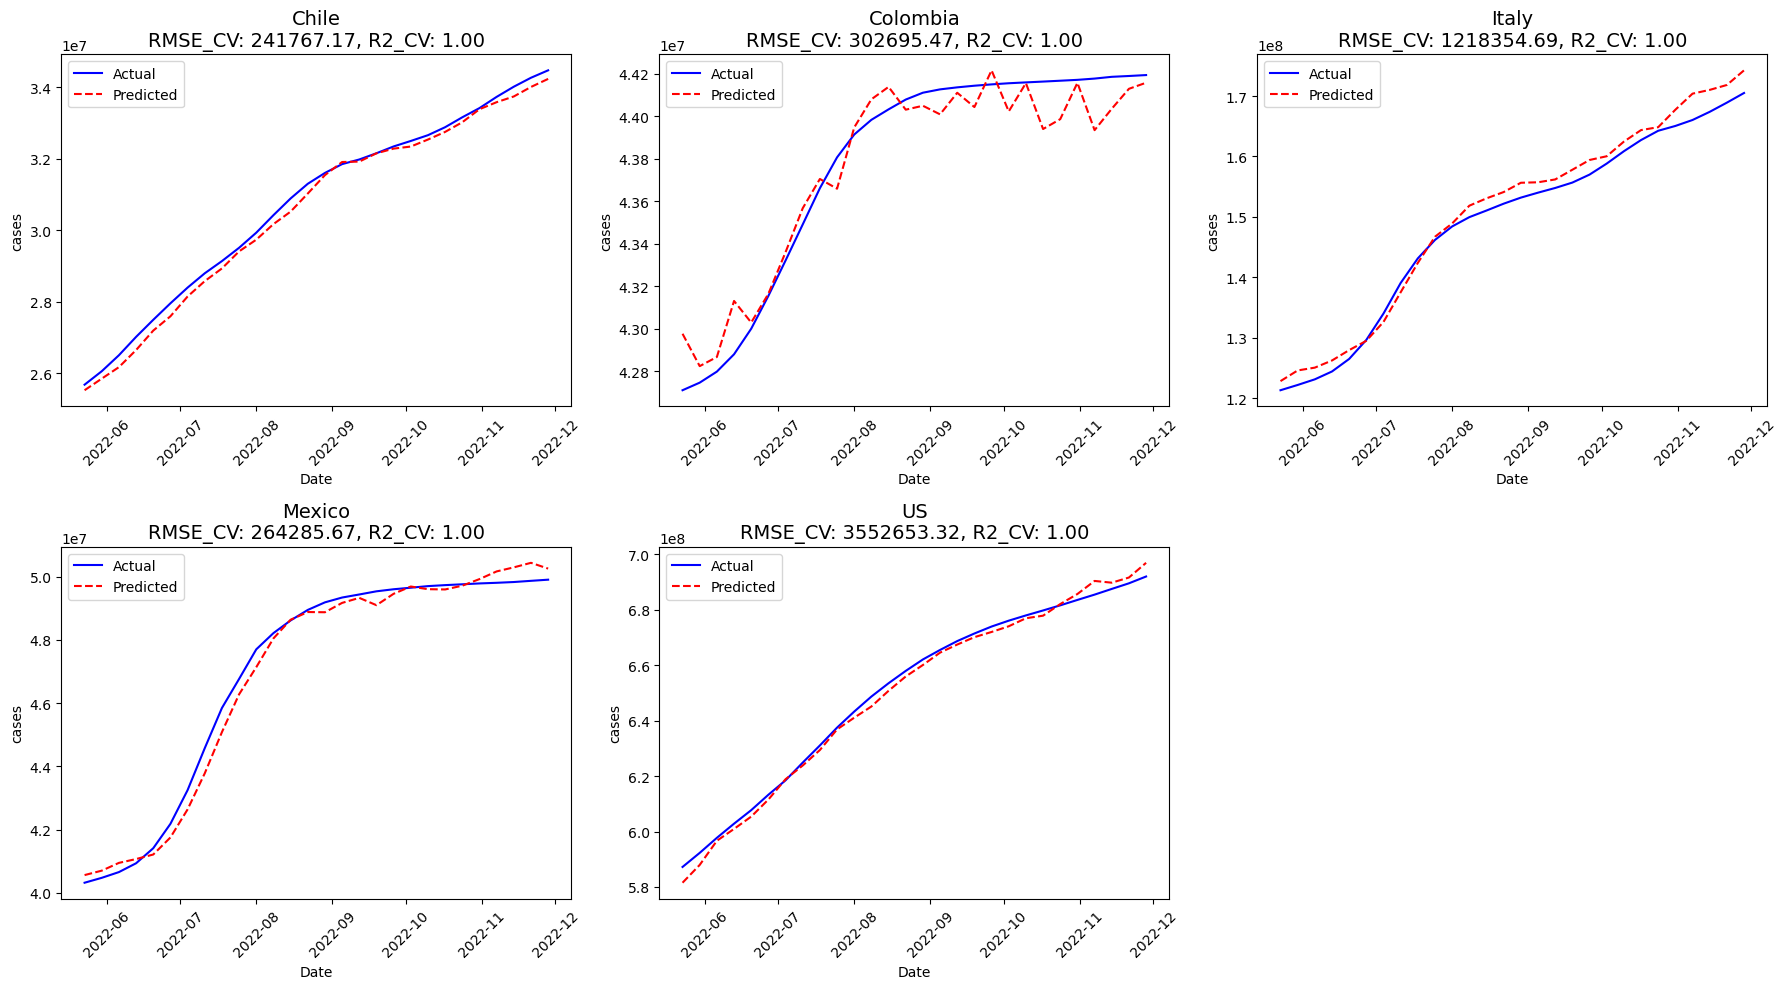

In [34]:
# Linear regression
plot_predictions_cv(df_og, 'cases', LinearRegression())

c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.654e+12, tolerance: 1.460e+12
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.754e+12, tolerance: 1.461e+12
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisati

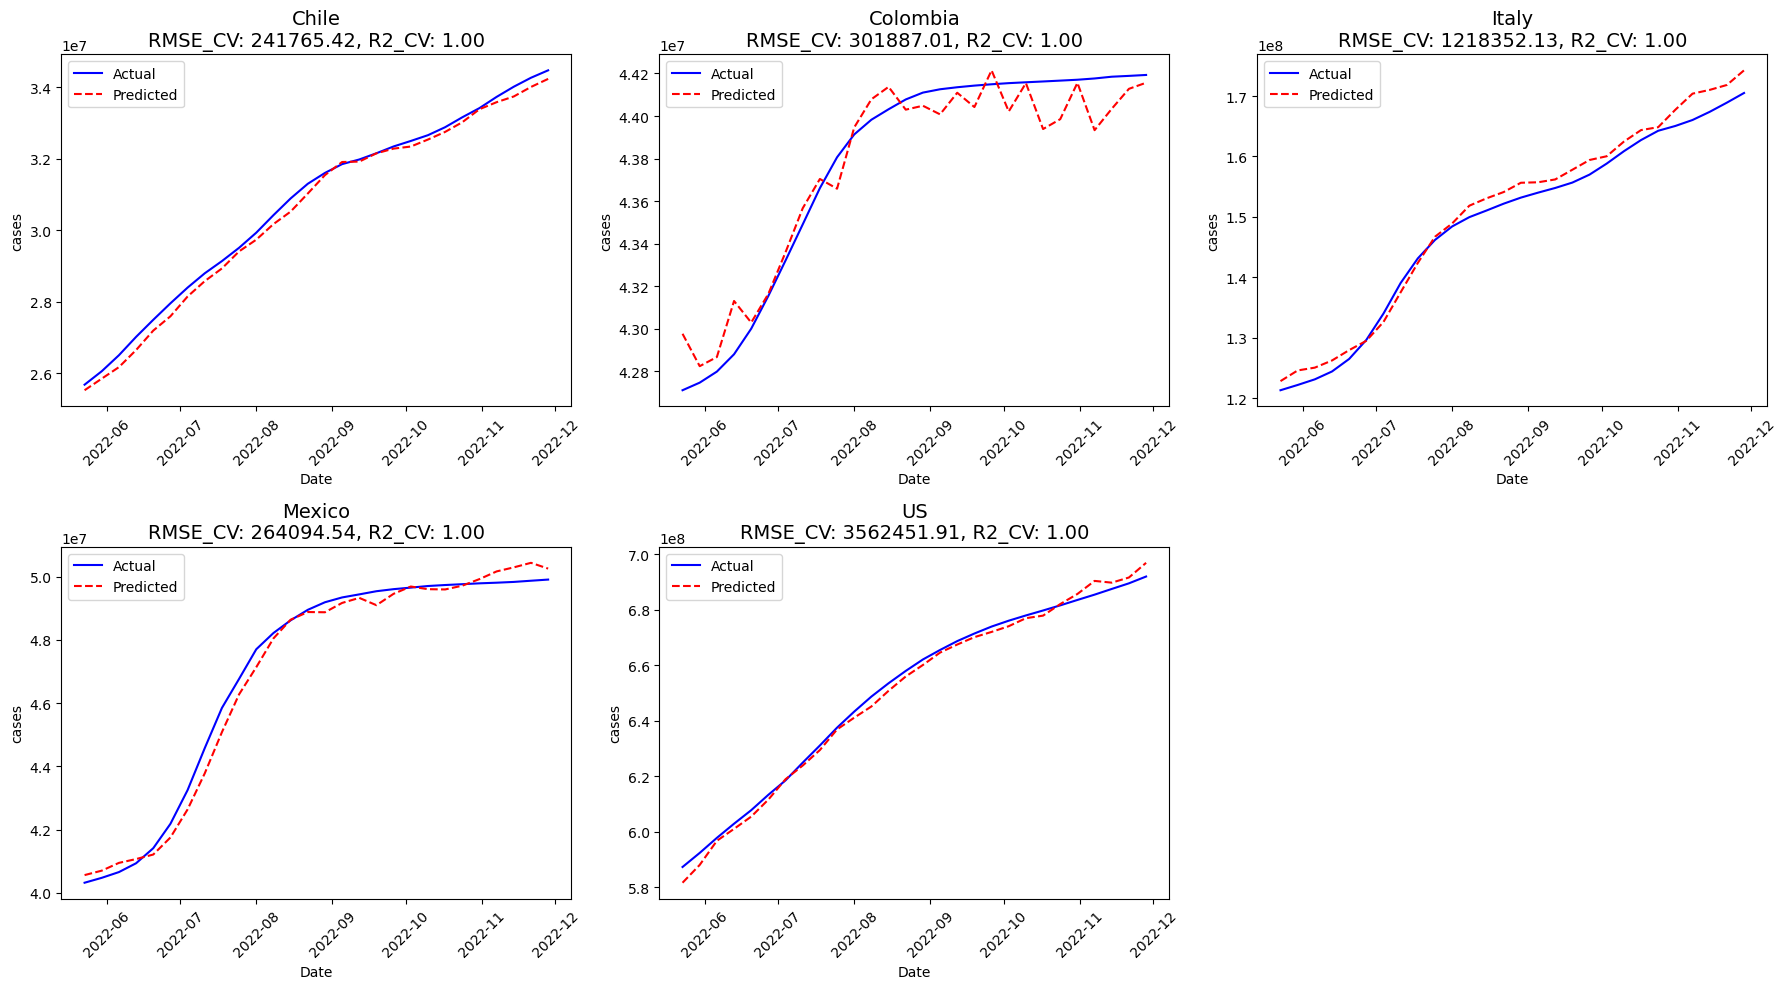

In [35]:
# Lasso
plot_predictions_cv(df_og, 'cases', Lasso(alpha = 1))

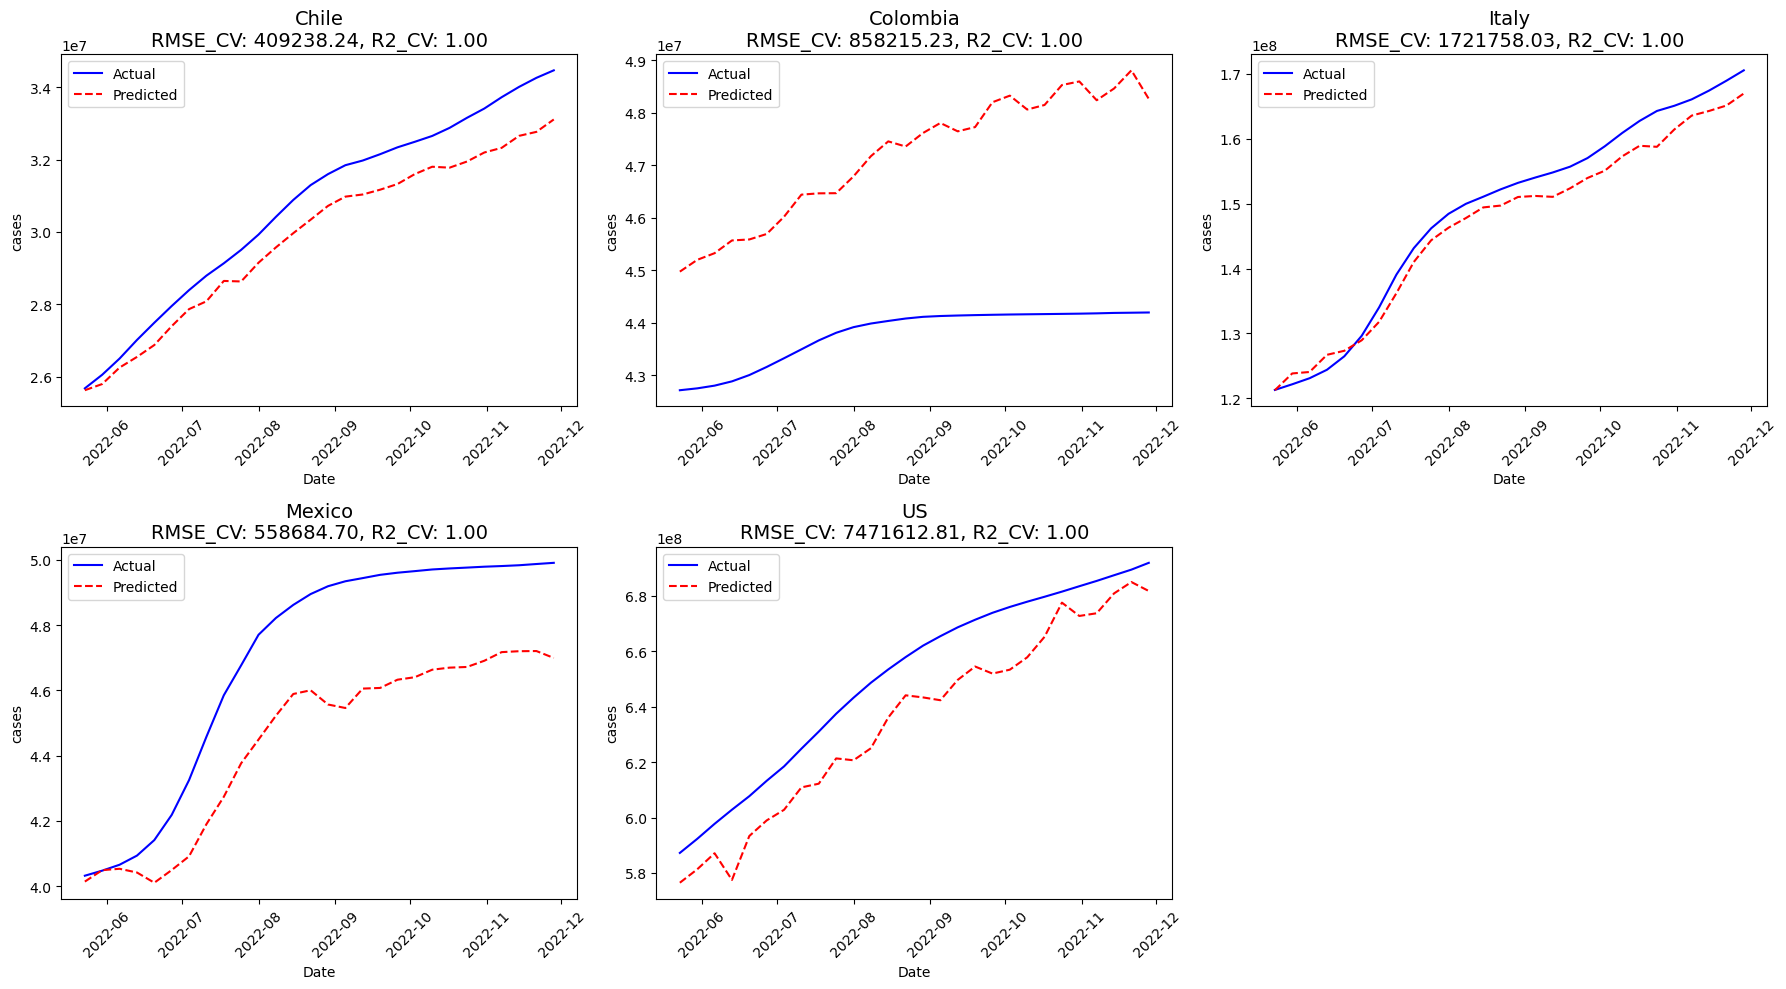

In [36]:
# Ridge
plot_predictions_cv(df_og, 'cases', Ridge(alpha=1))

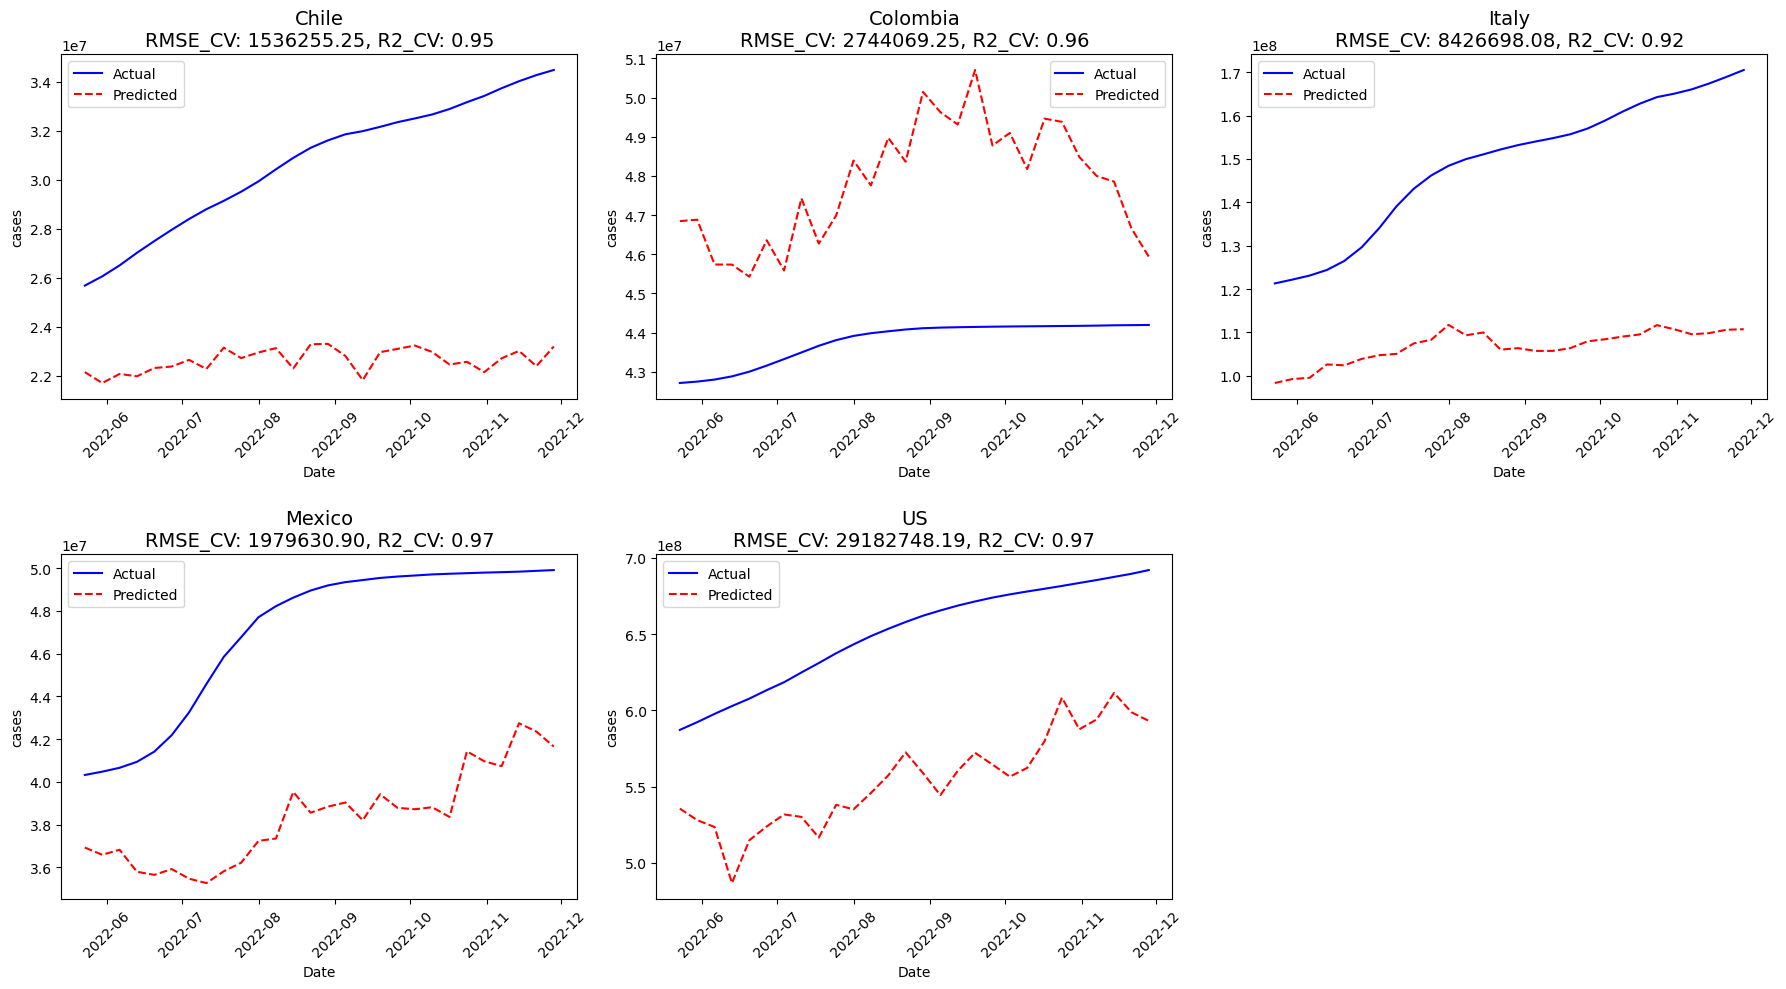

In [37]:
# ElasticNet
plot_predictions_cv(df_og, 'cases', ElasticNet(alpha = 1, l1_ratio=0.5))

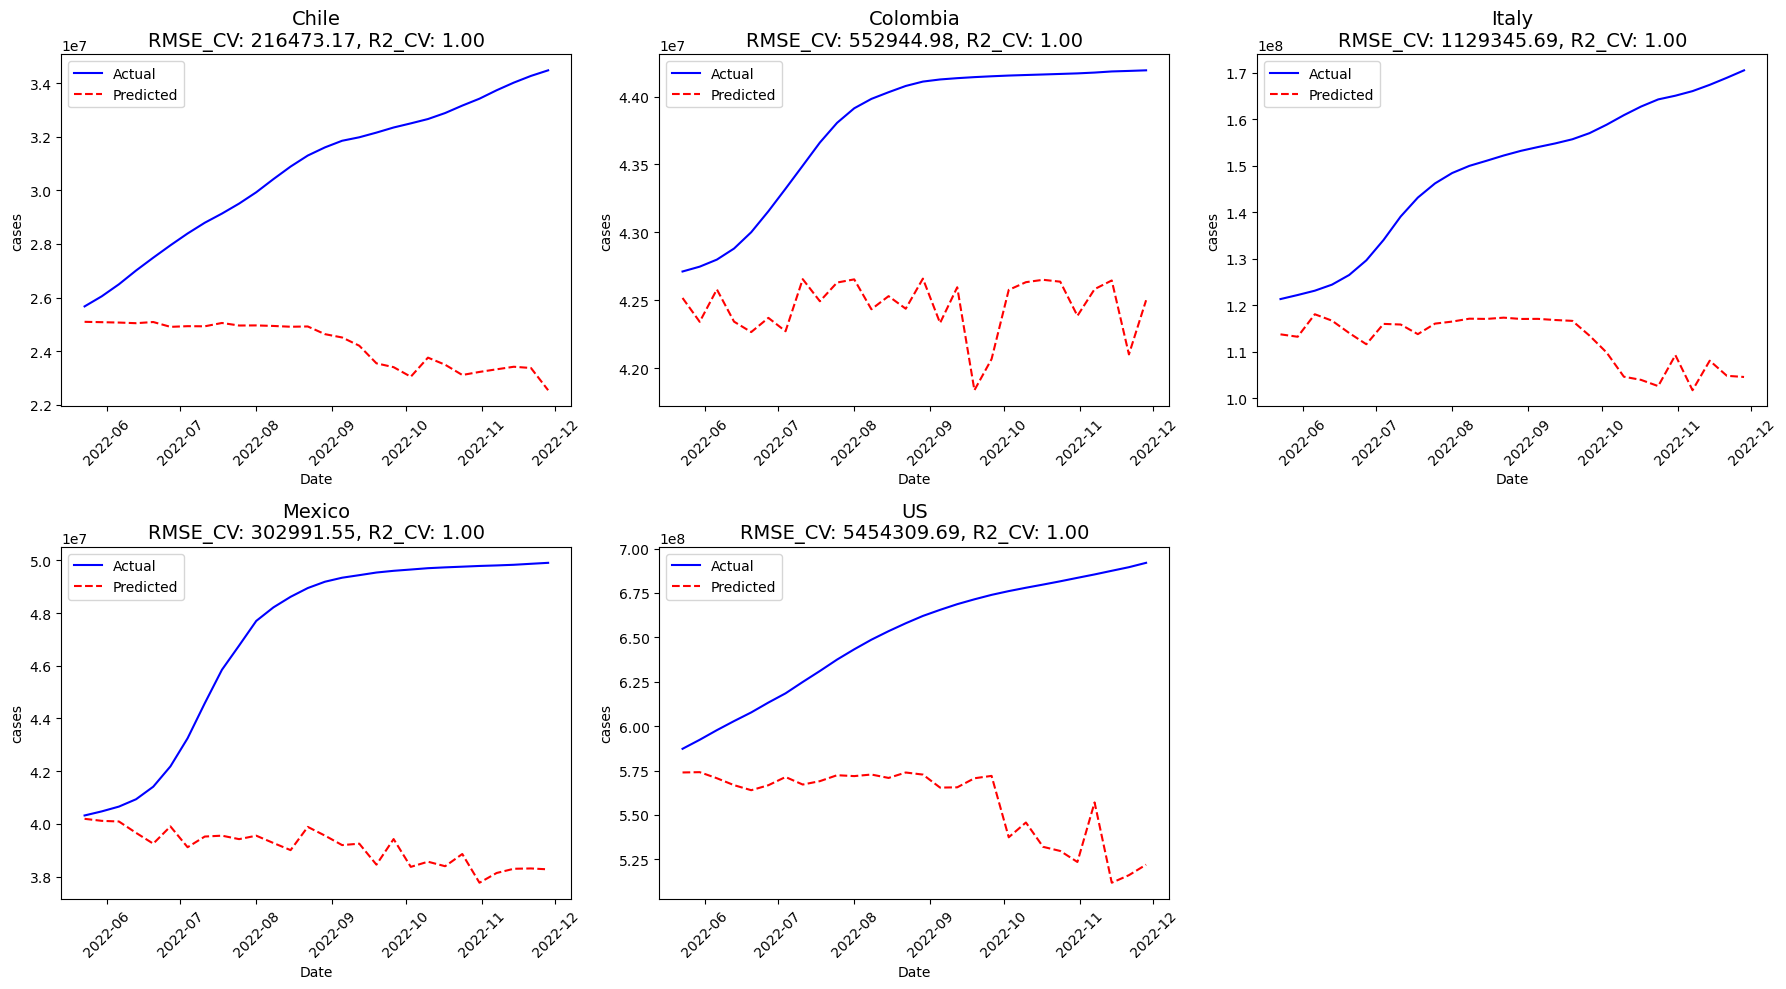

In [38]:
# RF
plot_predictions_cv(df_og, 'cases',RandomForestRegressor(n_estimators=100, random_state=42))

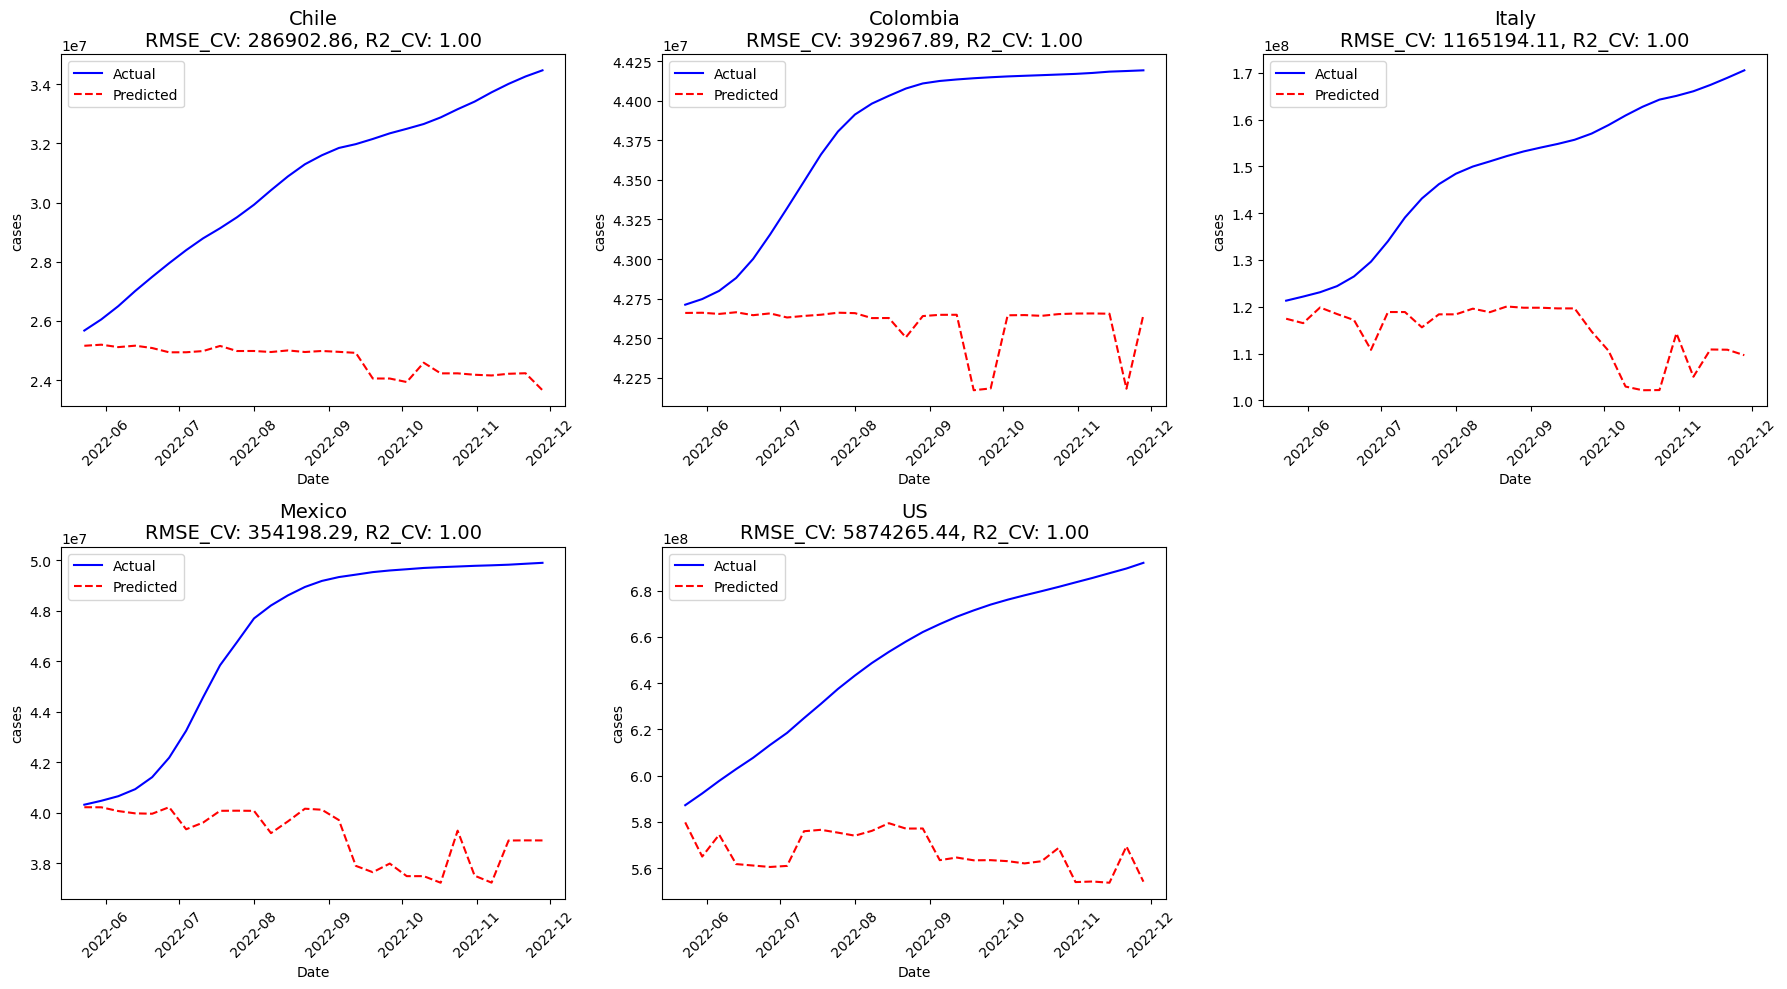

In [39]:
# Gradient Boosting
plot_predictions_cv(df_og, 'cases', GradientBoostingRegressor(n_estimators=100, random_state=42))

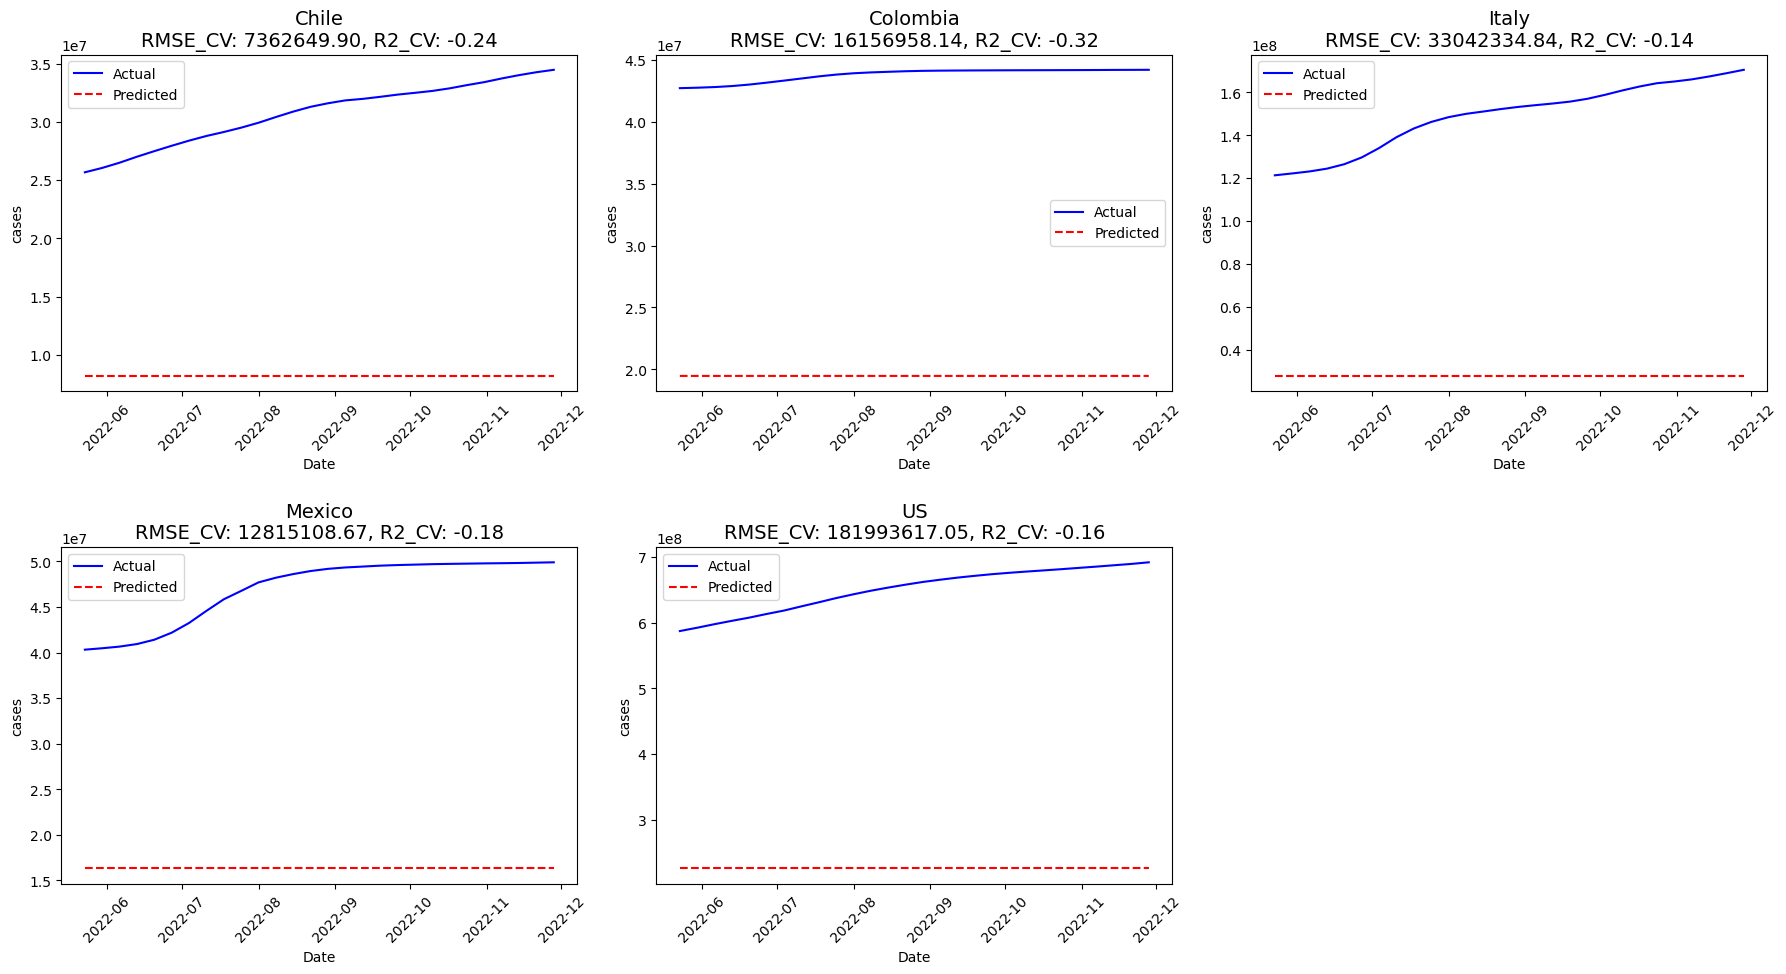

In [40]:
# SVM
plot_predictions_cv(df_og, 'cases',  SVR(kernel='rbf'))

c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.762e+15, tolerance: 6.748e+14
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.727e+15, tolerance: 6.027e+14
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisati

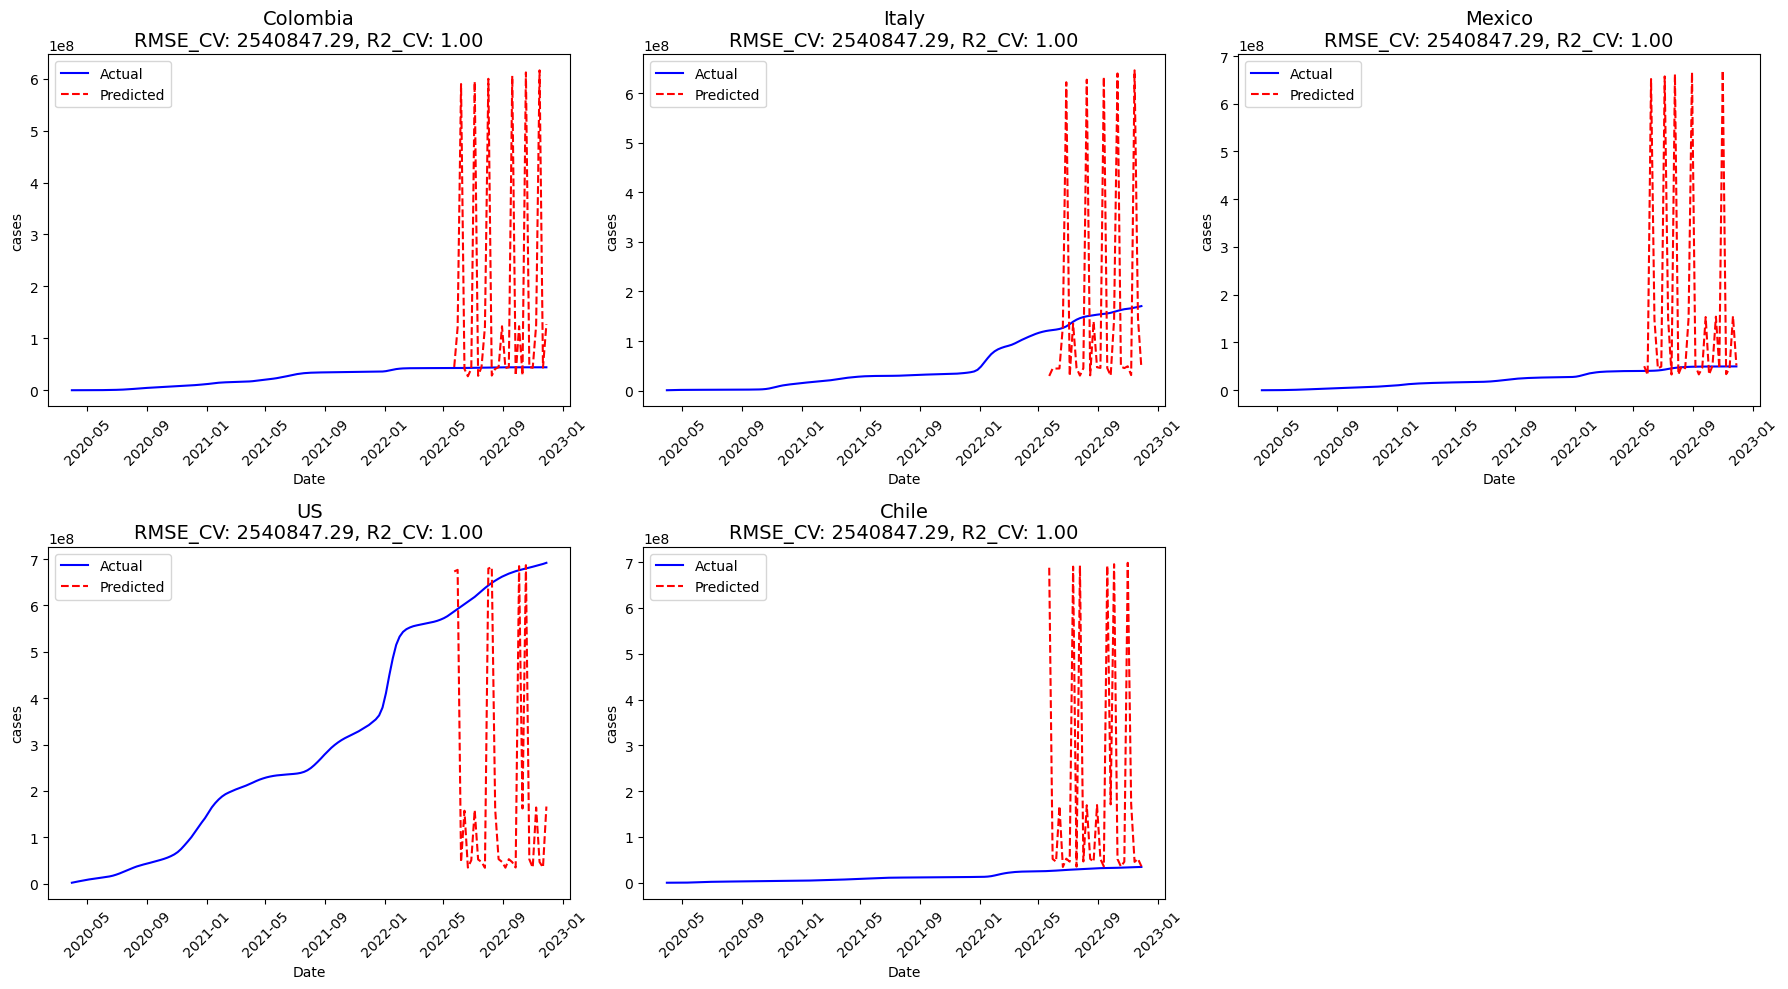

In [41]:
# Lasso for all at once
plot_predictions_all(df, 'cases', Lasso(alpha = 1))

## Lagged

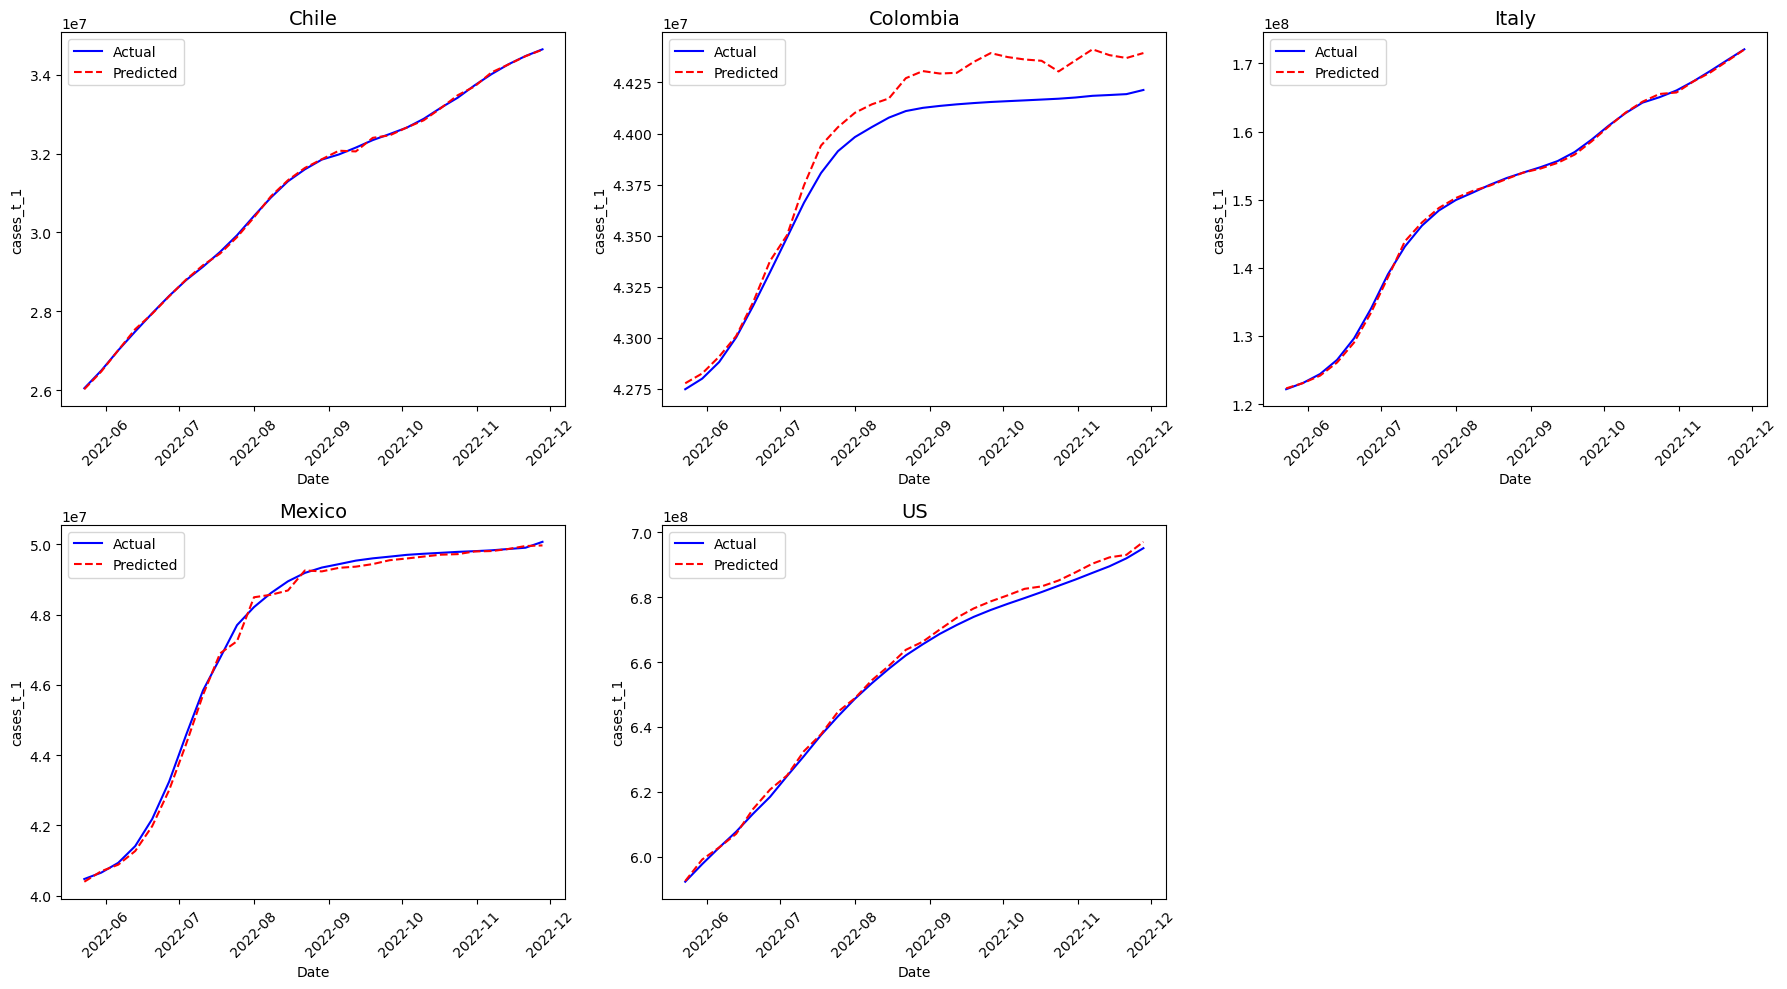

In [42]:
# linear model
plot_predictions_cv_forecast(df_og, 'cases_t_1', LinearRegression())

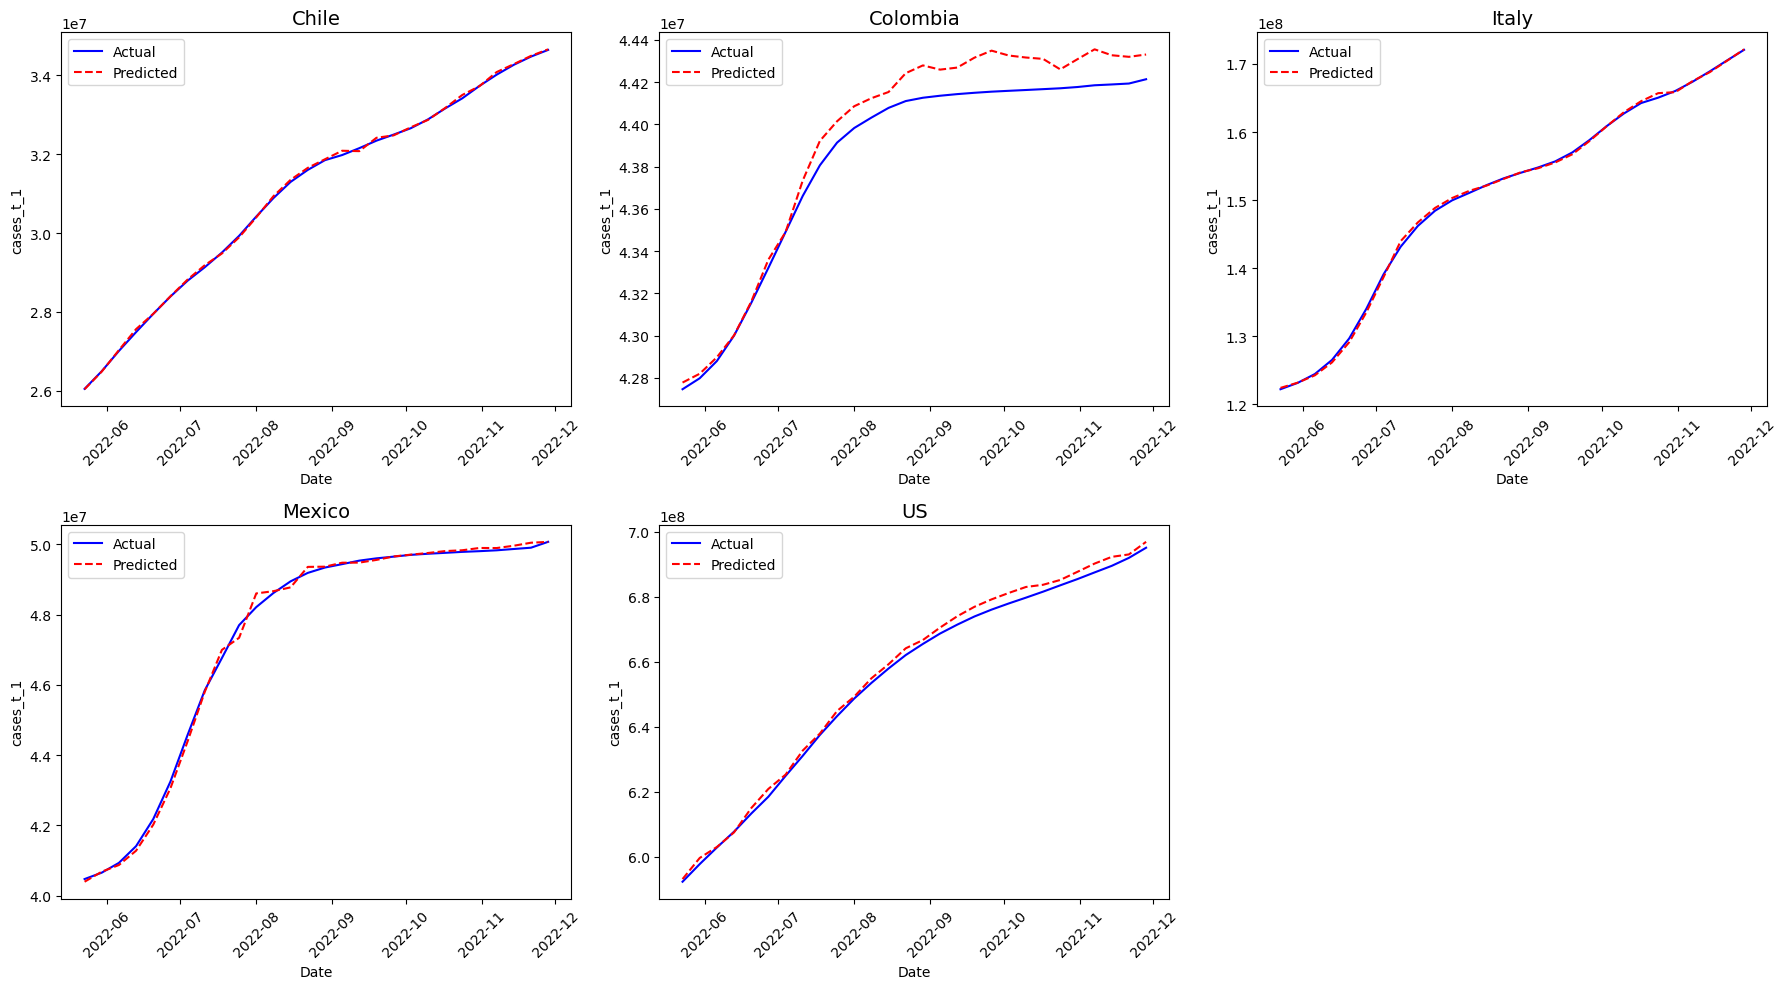

In [43]:
# Lasso
plot_predictions_cv_forecast(df_og, 'cases_t_1', Lasso())

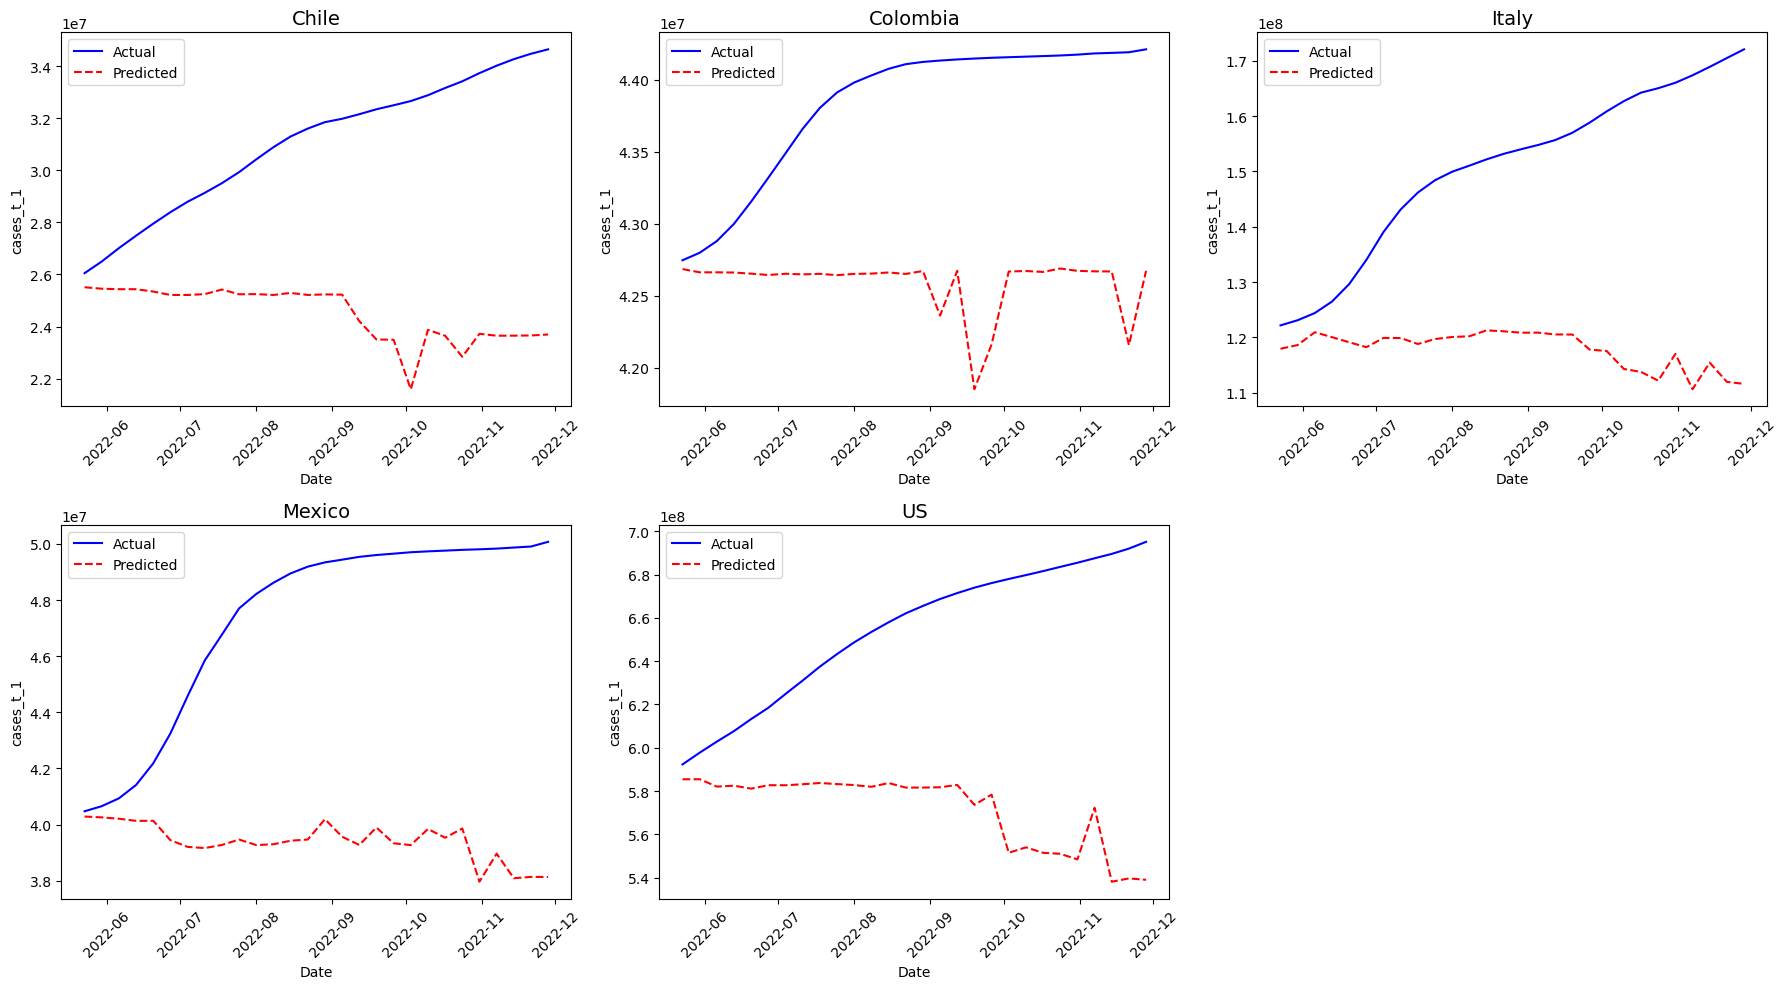

In [44]:
# Gradient Boosting
plot_predictions_cv_forecast(df_og, 'cases_t_1', GradientBoostingRegressor())

# Check Explainability

In [45]:
def plot_coefficients_by_country(df, target_variable, model):
    country_names = df['country'].unique()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for idx, country_name in enumerate(country_names):
        country_df = df[df['country'] == country_name].reset_index(drop=True)

        split_country_idx = int(len(country_df) * 0.8)
        df_train = country_df.iloc[:split_country_idx]

        drop_columns = [target_variable, 'date', 'country']
        if target_variable == 'new_cases':
            drop_columns.extend(['cases', 'cases_t_4', 'cases_t_1'])
        elif target_variable == 'cases':
            drop_columns.extend(['new_cases', 'cases_t_4', 'cases_t_1'])
        elif target_variable == 'cases_t_4':
            drop_columns.extend(['cases_lag1', 'cases_t_1'])
        elif target_variable == 'cases_t_1':
            drop_columns.extend(['cases_lag1', 'cases_t_4'])

        X_train = df_train.drop(columns=drop_columns)
        y_train = df_train[target_variable]

        dummy_cols = [col for col in X_train.columns if set(X_train[col].unique()) <= {0, 1}]
        numeric_cols = [col for col in X_train.columns if col not in dummy_cols]

        scaler = StandardScaler()
        X_train_scaled_numeric = scaler.fit_transform(X_train[numeric_cols])
        X_train_scaled = np.concatenate([X_train_scaled_numeric, X_train[dummy_cols].values], axis=1)

        feature_names = numeric_cols + dummy_cols

        model.fit(X_train_scaled, y_train)

        if hasattr(model, 'coef_'):
            importance = model.coef_
            title = "Coefficients"
        elif hasattr(model, 'feature_importances_'):
            importance = model.feature_importances_
            title = "Feature Importances"
        else:
            raise ValueError("Model does not have coefficients or feature importances to plot.")

        sorted_idx = np.argsort(np.abs(importance))[::-1]

        axes[idx].bar(np.array(feature_names)[sorted_idx], importance[sorted_idx])
        axes[idx].set_title(f"{country_name} - {title}", fontsize=14)
        axes[idx].set_xlabel("Features", fontsize=12)
        axes[idx].set_ylabel(title, fontsize=12)
        axes[idx].tick_params(axis='x', rotation=90)

    for i in range(len(country_names), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()




## OLS

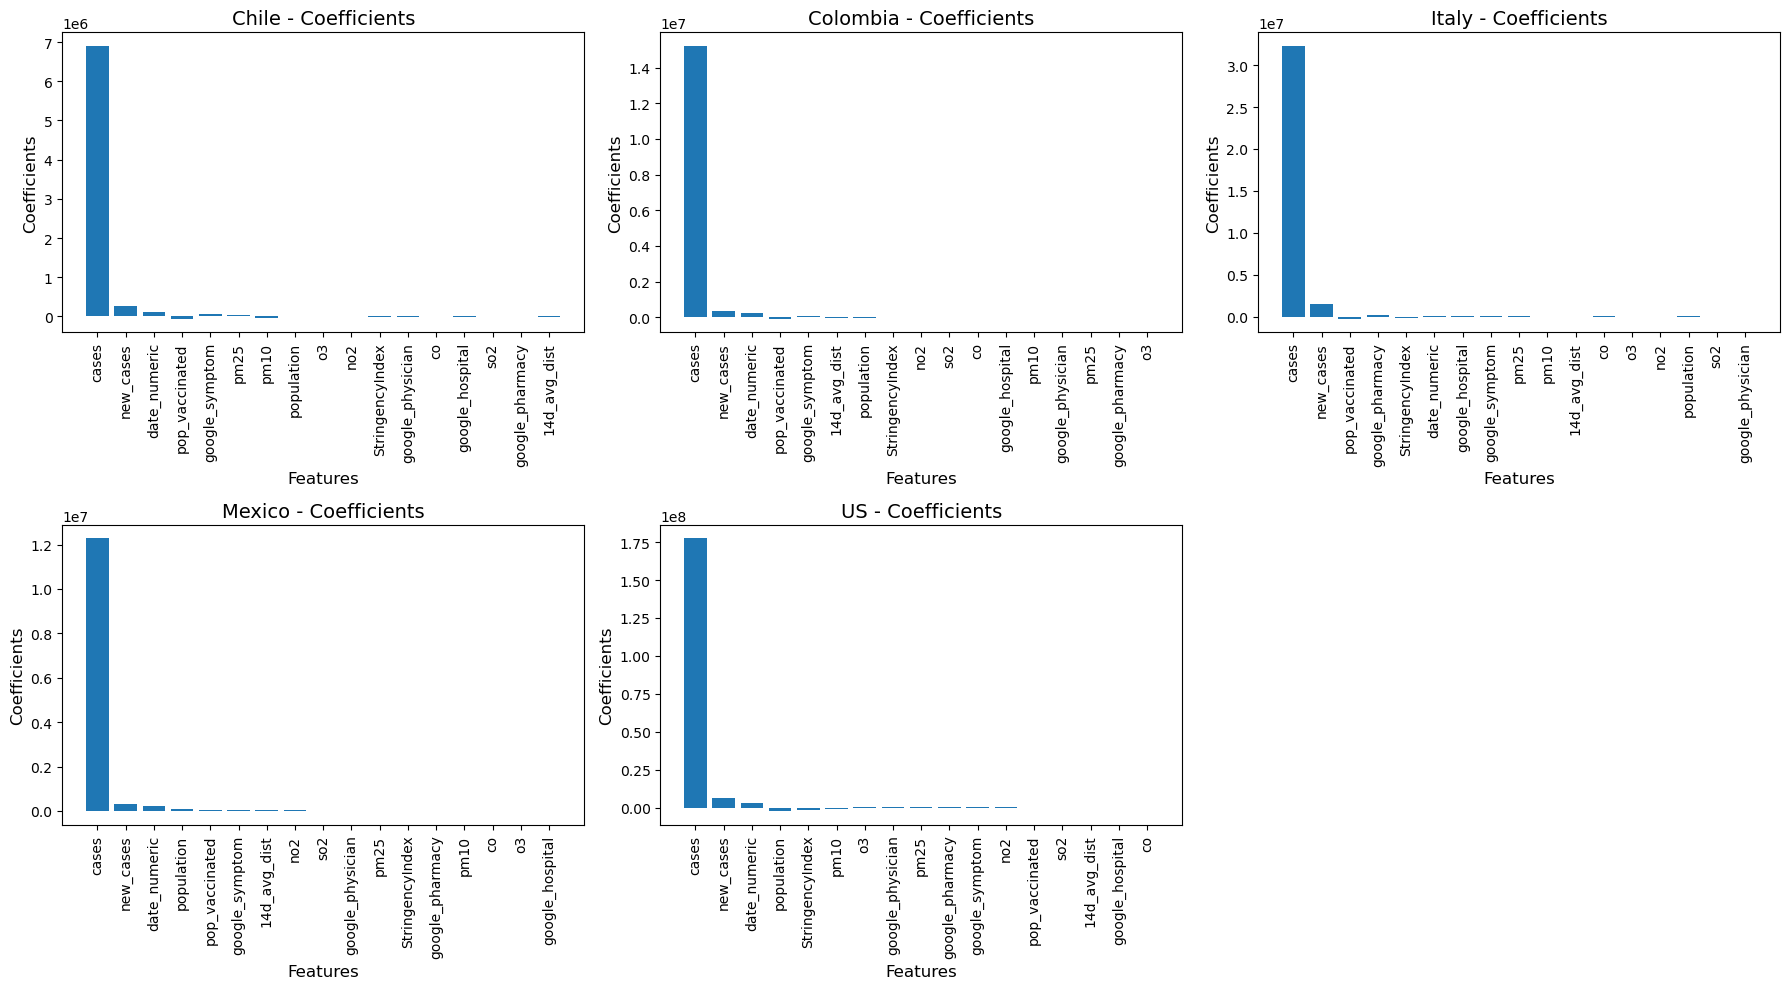

In [46]:
plot_coefficients_by_country(df_og, 'cases_t_1', LinearRegression())

## Lasso

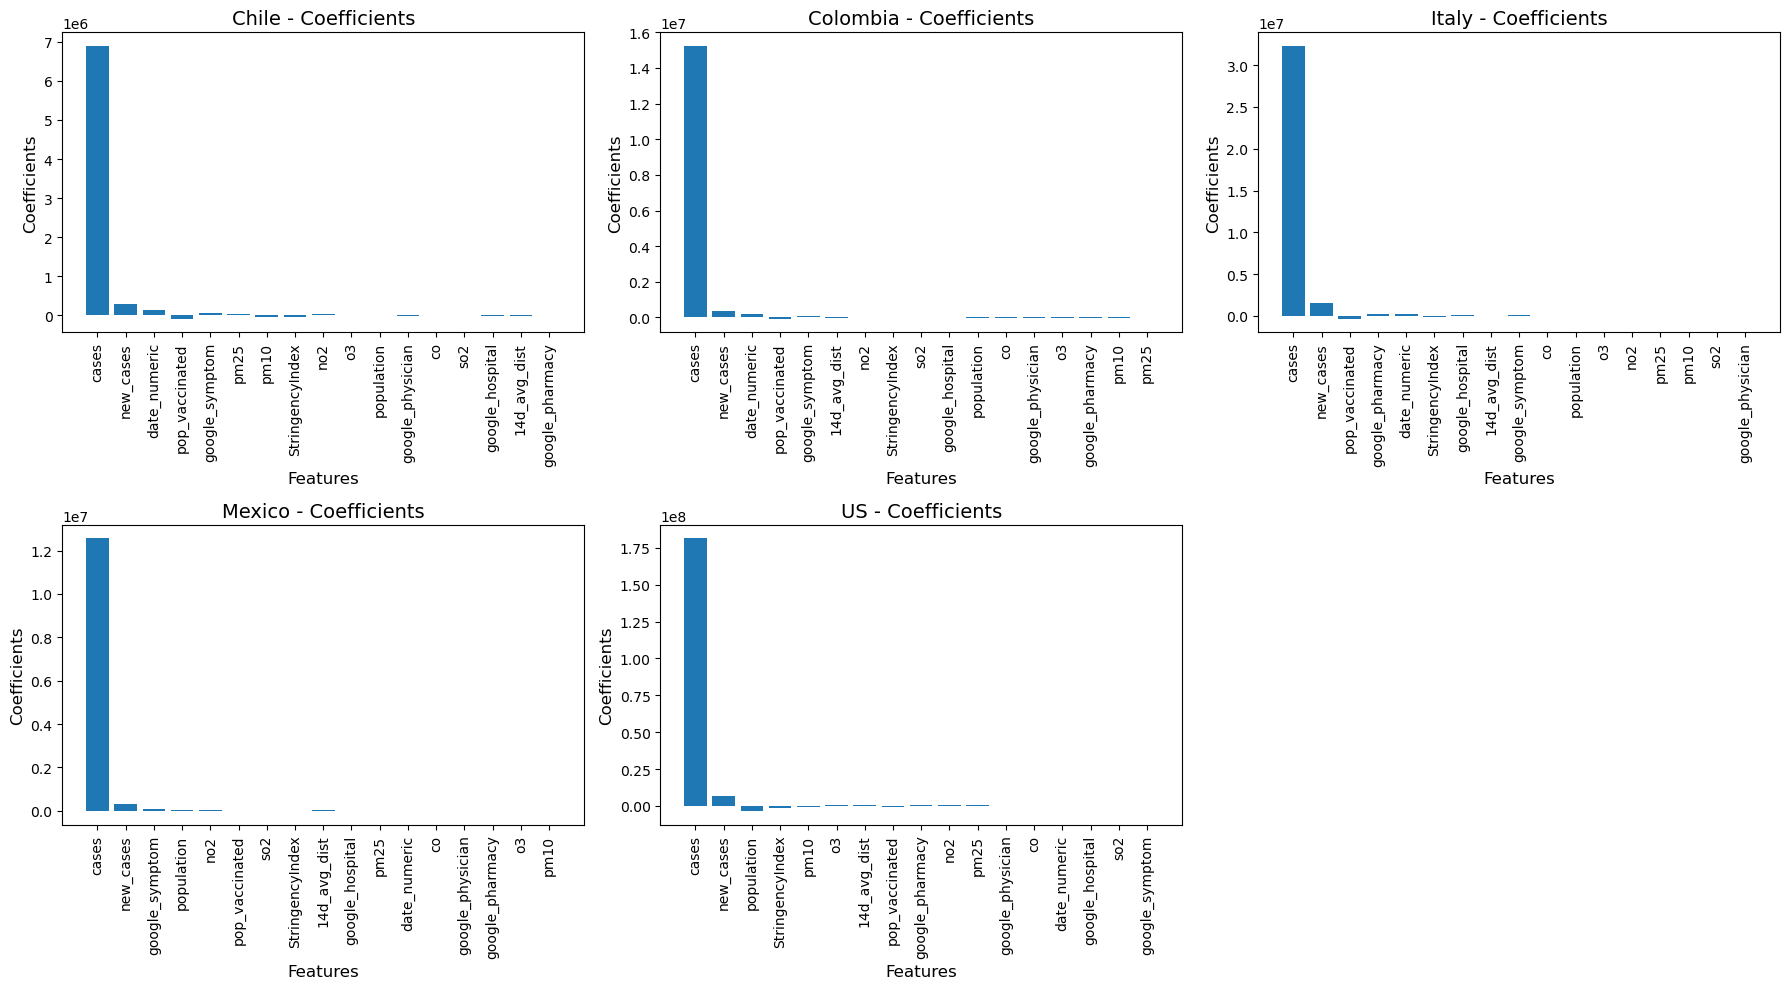

In [47]:
plot_coefficients_by_country(df_og, 'cases_t_1', Lasso())

## Ridge

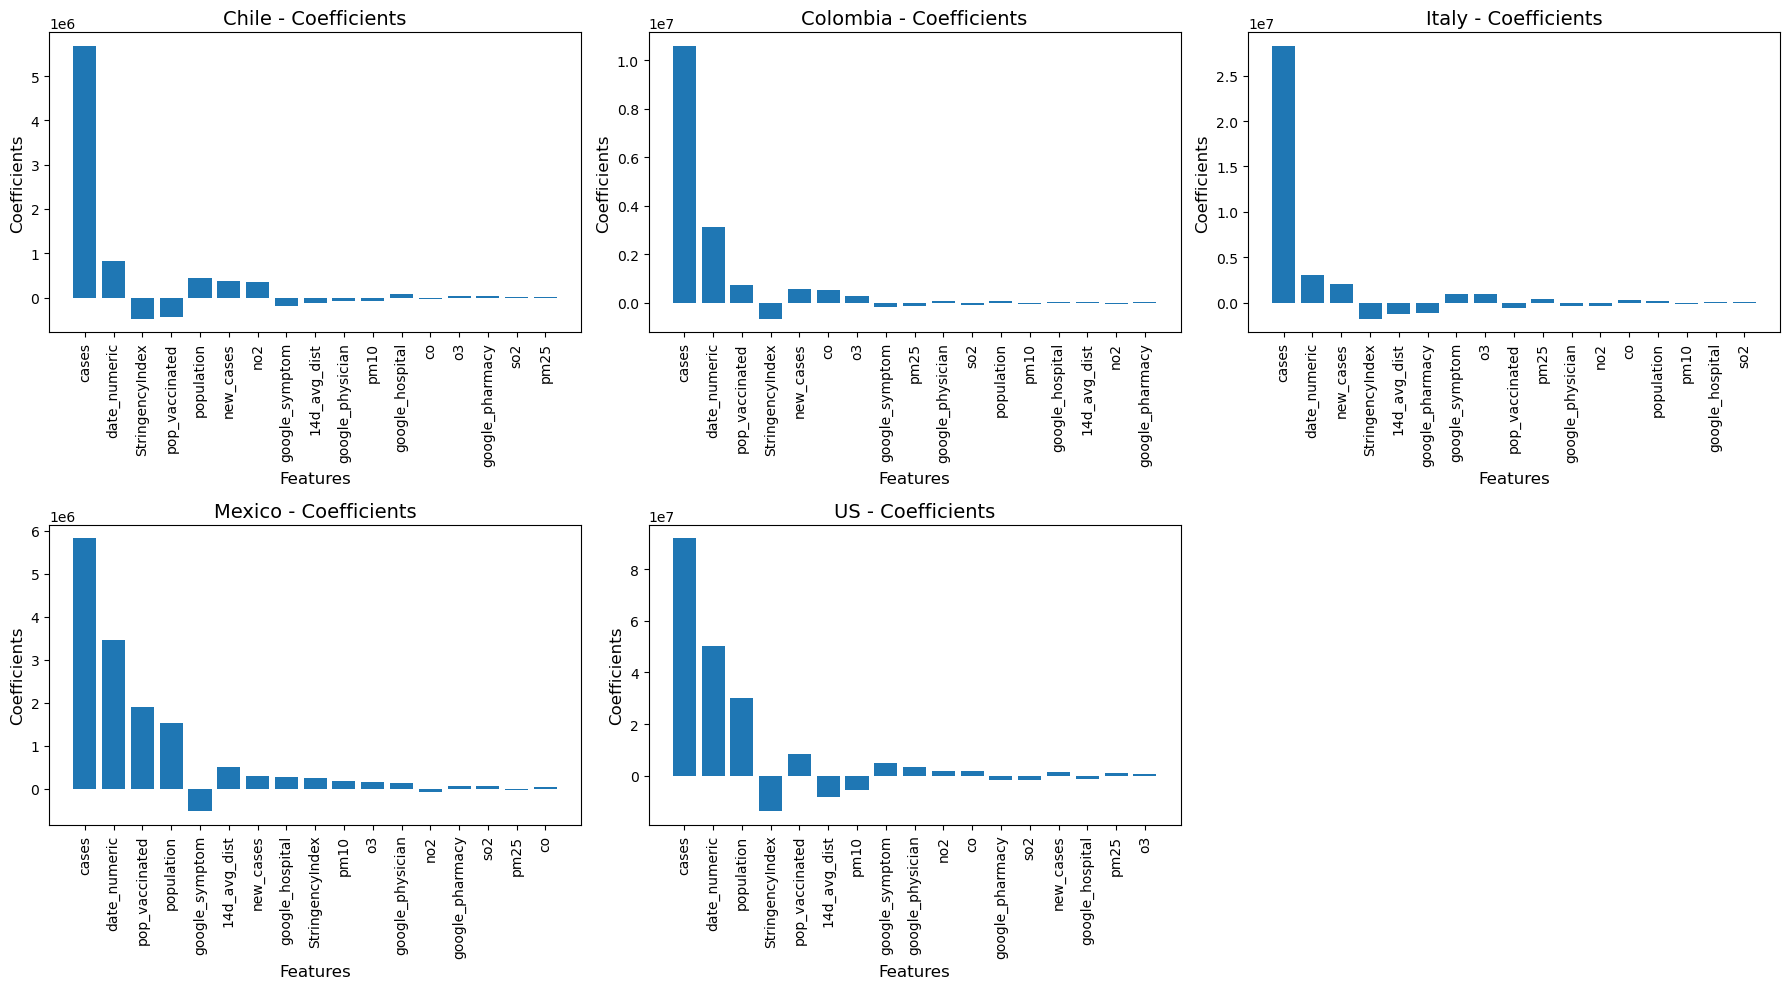

In [48]:
plot_coefficients_by_country(df_og, 'cases_t_1', Ridge())

## ElasticNet

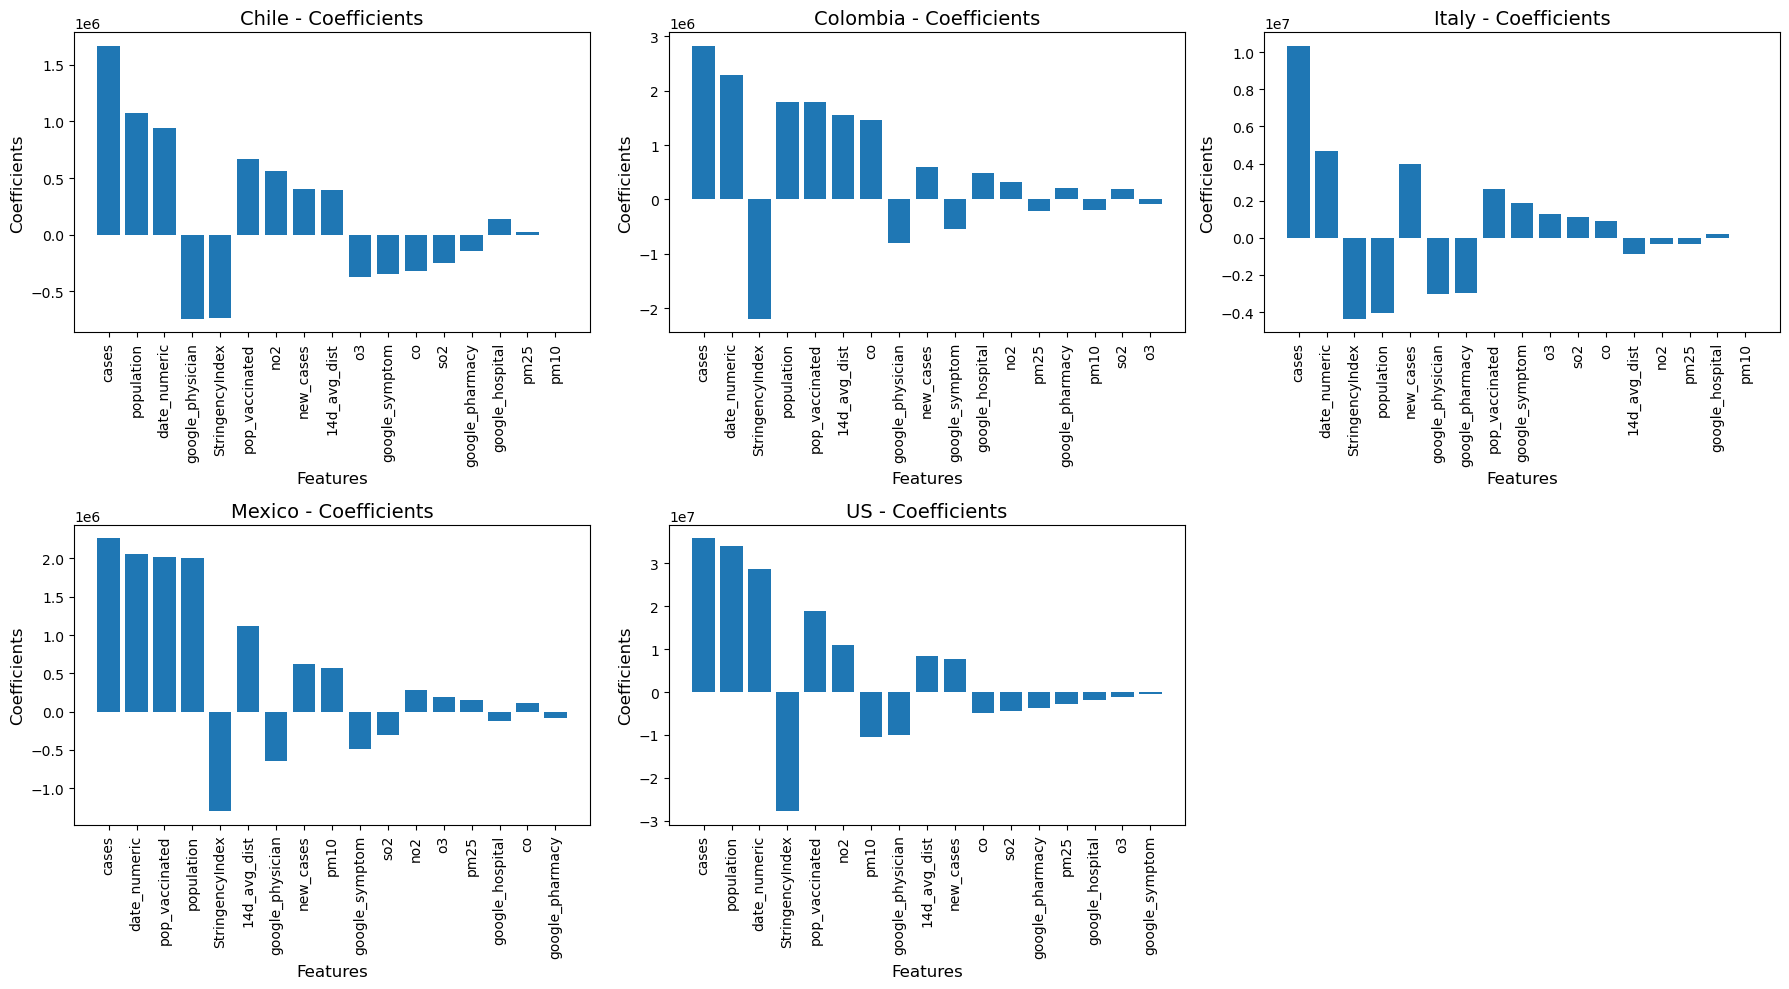

In [49]:
plot_coefficients_by_country(df_og, 'cases_t_1', ElasticNet())

## Random Forest

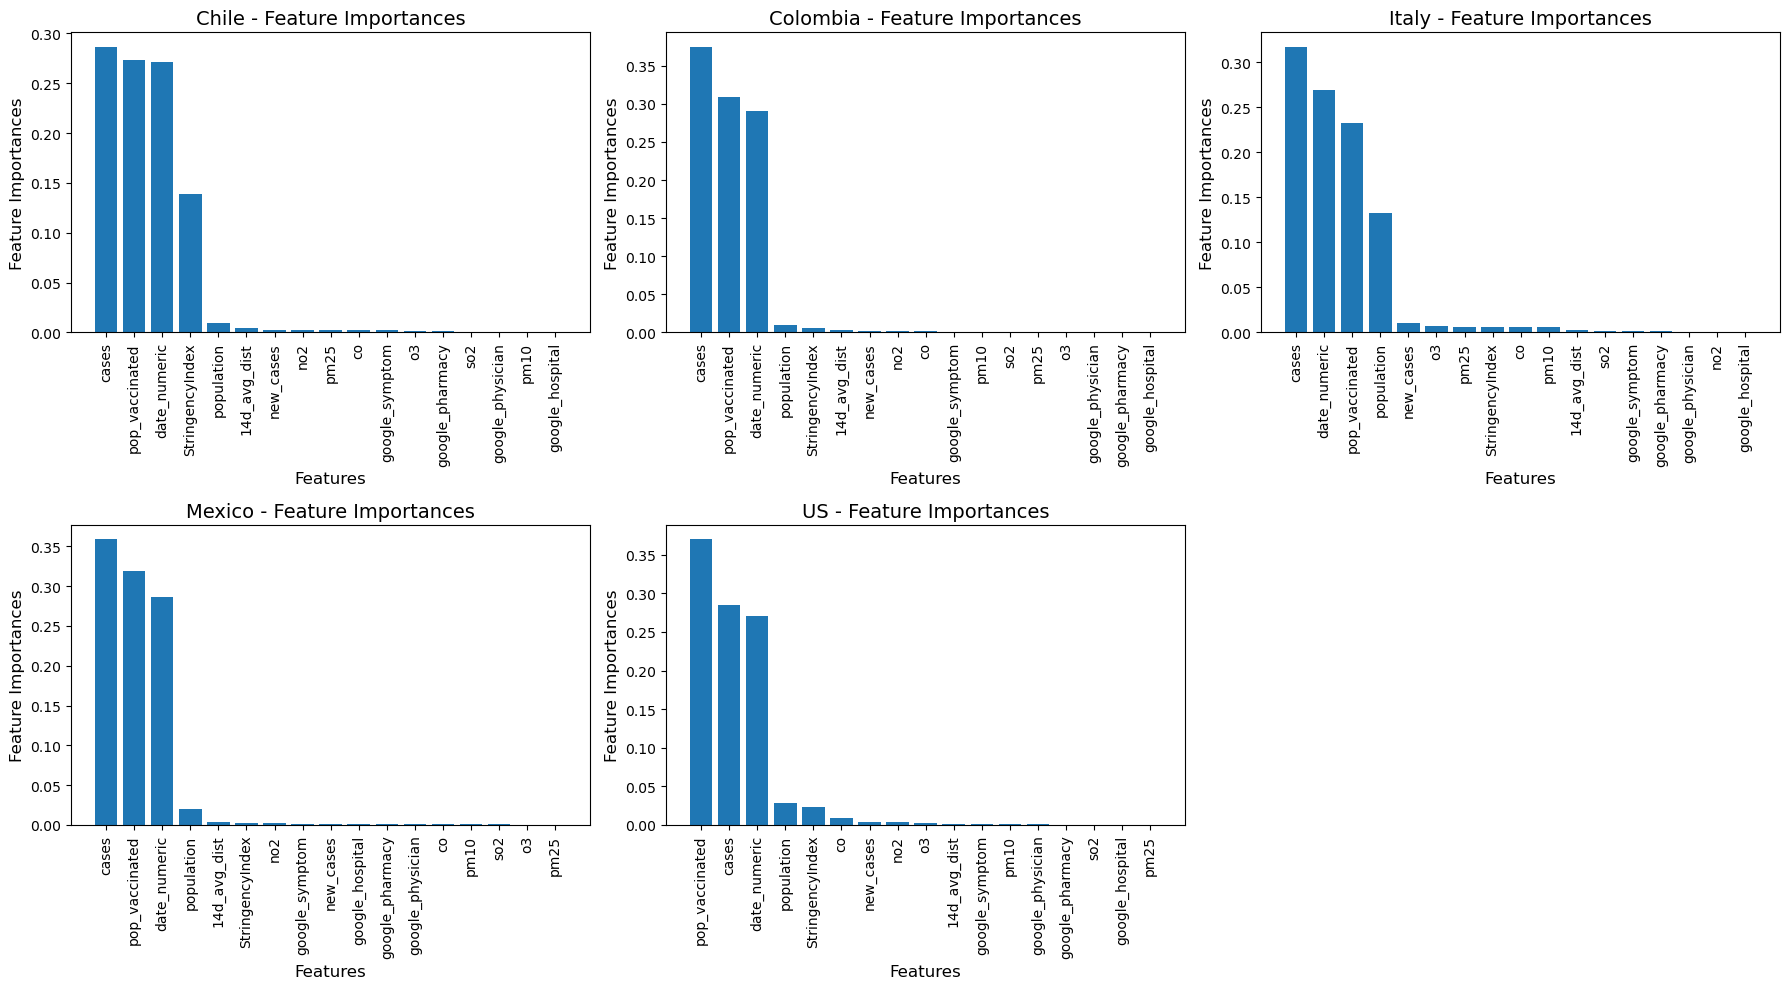

In [50]:
plot_coefficients_by_country(df_og, 'cases_t_1', RandomForestRegressor())

## Gradient Boosting

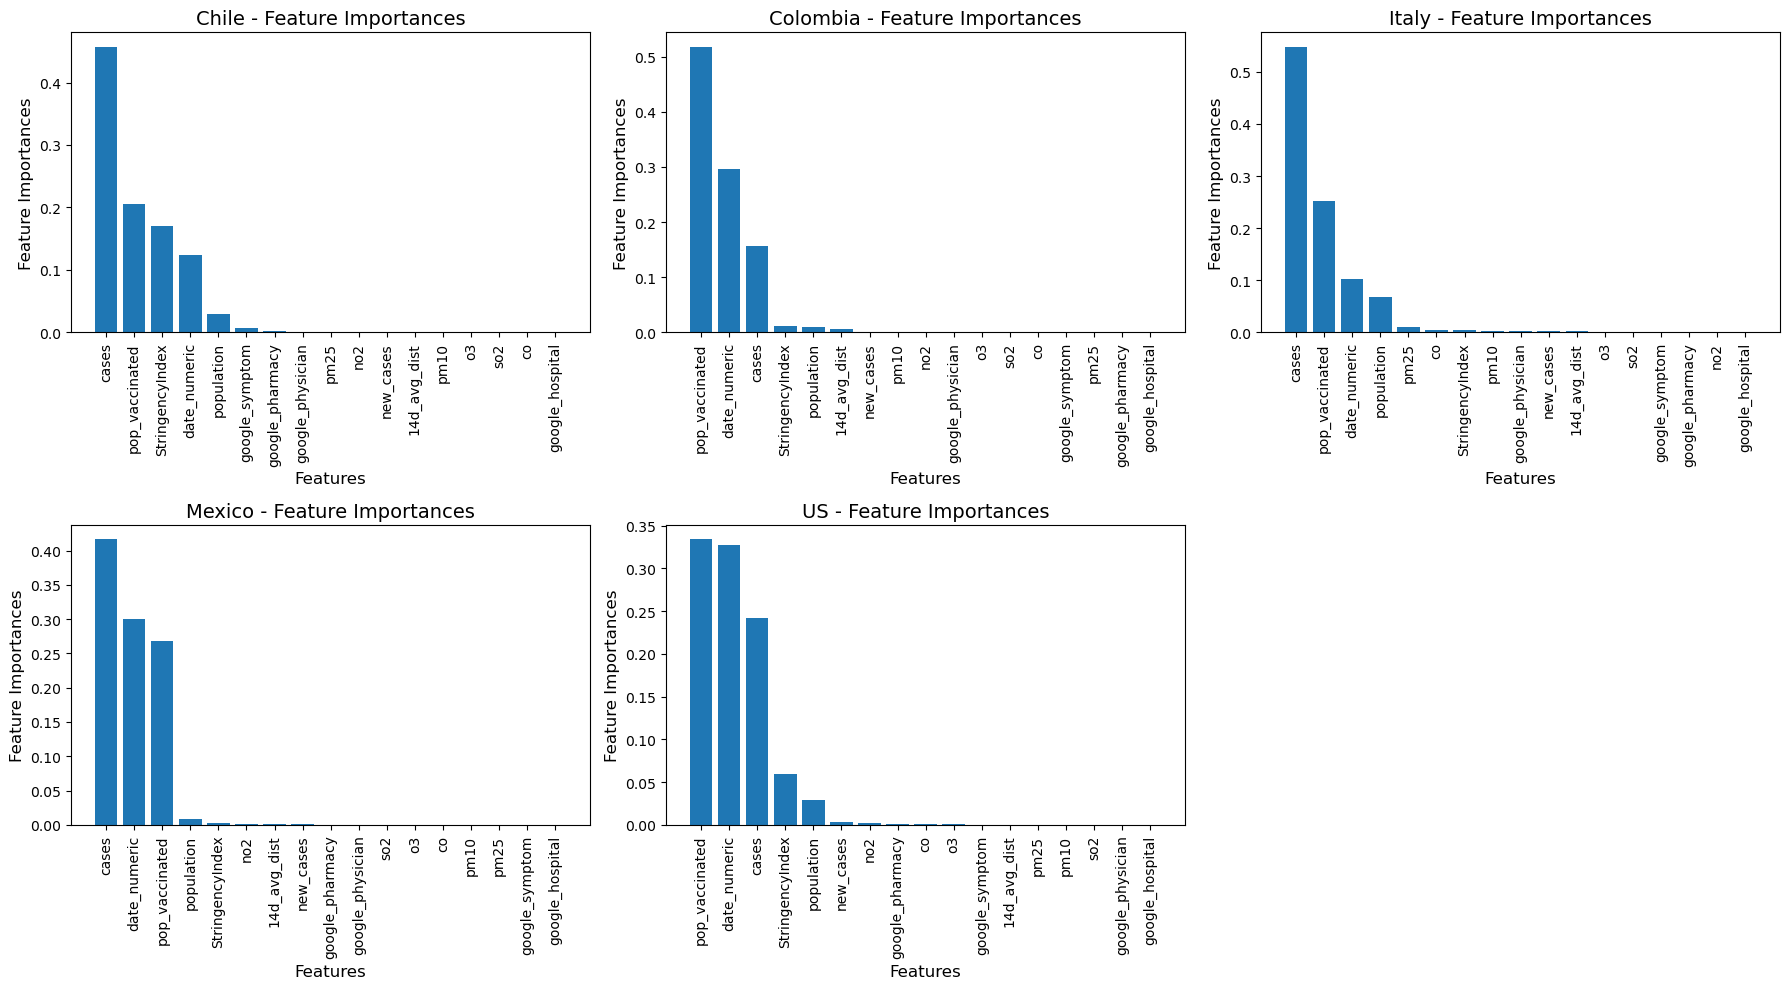

In [51]:
plot_coefficients_by_country(df_og, 'cases_t_1', GradientBoostingRegressor())

# Feature Engineering

Find the lags that best predict the ```cases_t_1``` for each variable and contrast to each ```country```

In [52]:
def variable_lag_impact(df, target_variable, max_lag=5):
    country_names = df['country'].unique()
    results = {}

    for country_name in country_names:
        country_df = df[df['country'] == country_name].reset_index(drop=True)

        drop_columns = [target_variable, 'date', 'country']
        if target_variable == 'new_cases':
            drop_columns.extend(['cases', 'cases_t_4', 'cases_t_1'])
        elif target_variable == 'cases':
            drop_columns.extend(['new_cases', 'cases_t_4', 'cases_t_1'])
        elif target_variable == 'cases_t_4':
            drop_columns.extend(['cases_lag1', 'cases_t_1'])
        elif target_variable == 'cases_t_1':
            drop_columns.extend(['cases_lag1', 'cases_t_4'])

        variables = [col for col in country_df.columns if col not in drop_columns]
        corr_dict = {}

        for var in variables:
            lag_corrs = []
            for lag in range(1, max_lag + 1):
                shifted_var = country_df[var].shift(lag)
                corr = country_df[target_variable].corr(shifted_var)
                lag_corrs.append(corr)
            corr_dict[var] = lag_corrs

        results[country_name] = pd.DataFrame(corr_dict, index=[f'lag_{i}' for i in range(1, max_lag + 1)]).T

    return results

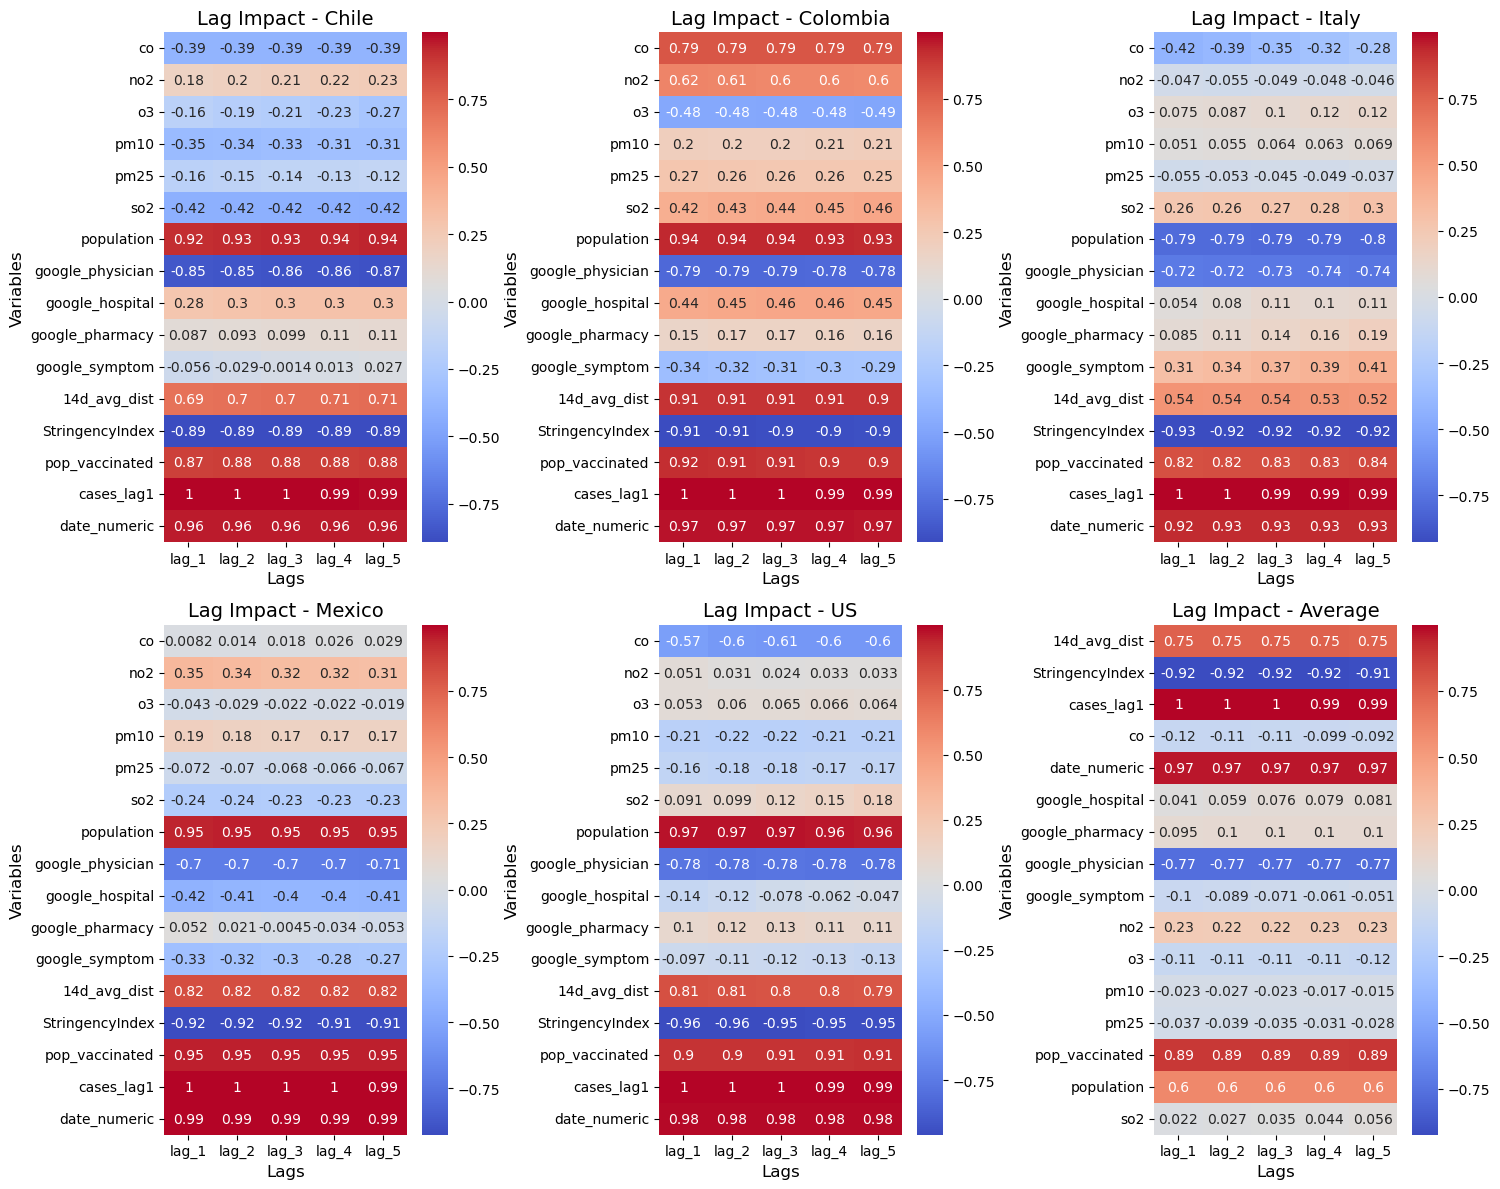

In [53]:
results = variable_lag_impact(df_og, target_variable='cases', max_lag=5)

country_names = list(results.keys())
n_cols = (len(country_names) + 2) // 2
fig, axes = plt.subplots(2, n_cols, figsize=(5 * n_cols, 12))
axes = axes.flatten()

# Plot country-specific heatmaps
for idx, country_name in enumerate(country_names):
    sns.heatmap(results[country_name], annot=True, cmap='coolwarm', ax=axes[idx])
    axes[idx].set_title(f'Lag Impact - {country_name}', fontsize=14)
    axes[idx].set_xlabel('Lags', fontsize=12)
    axes[idx].set_ylabel('Variables', fontsize=12)

# Compute average table
average_df = pd.concat(results.values()).groupby(level=0).mean()

# Plot average heatmap
sns.heatmap(average_df, annot=True, cmap='coolwarm', ax=axes[len(country_names)])
axes[len(country_names)].set_title('Lag Impact - Average', fontsize=14)
axes[len(country_names)].set_xlabel('Lags', fontsize=12)
axes[len(country_names)].set_ylabel('Variables', fontsize=12)

# Remove empty subplots
for idx in range(len(country_names) + 1, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

Overall is ok to use just one lag for the covariates